In [ ]:
# INSTALL ARIAL (regular, bold, italic, bold-italic)
import os
import glob
import urllib.request
import matplotlib
import matplotlib.font_manager as fm

FACES = ['Arial.ttf', 'Arial_Bold.ttf', 'Arial_Italic.ttf', 'Arial_Bold_Italic.ttf']

MIRRORS = [
    'https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts'
]

# Prefer a system font directory so the fonts survive a runtime restart
try:
    FONT_DIR = '/usr/share/fonts/truetype/arial'
    os.makedirs(FONT_DIR, exist_ok=True)
except PermissionError:
    FONT_DIR = os.path.expanduser('~/.fonts/arial')
    os.makedirs(FONT_DIR, exist_ok=True)

for face in FACES:

    target = os.path.join(FONT_DIR, face)

    if os.path.exists(target) and os.path.getsize(target) > 50000:
        print(f'{face:22s} already installed')
        continue

    for base in MIRRORS:
        try:
            urllib.request.urlretrieve(f'{base}/{face}', target)

            # Confirm the file really is Arial before keeping it
            family = fm.FontProperties(fname=target).get_name()
            if family != 'Arial':
                raise ValueError(f'font family reported as {family!r}')

            print(f'{face:22s} installed ({os.path.getsize(target)} bytes)')
            break

        except Exception as error:
            if os.path.exists(target):
                os.remove(target)
            print(f'{face:22s} failed from {base} ({error})')

    else:
        raise RuntimeError(
            f'Could not install {face}. Check the runtime has internet access.'
        )

# Rebuild the system font cache
os.system('fc-cache -f > /dev/null 2>&1')

# Clear the matplotlib font cache so Arial is picked up on the next import
for cache_file in glob.glob(os.path.join(matplotlib.get_cachedir(), 'fontlist-v*.json')):
    os.remove(cache_file)

print(f'\nFonts installed to: {FONT_DIR}')


Arial.ttf              already installed
Arial_Bold.ttf         already installed
Arial_Italic.ttf       already installed
Arial_Bold_Italic.ttf  already installed

Fonts installed to: /usr/share/fonts/truetype/arial


In [ ]:
# REGISTER ARIAL WITH MATPLOTLIB AND VERIFY
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

for font_file in glob.glob('/usr/share/fonts/truetype/arial/*.ttf') + \
                 glob.glob(os.path.expanduser('~/.fonts/arial/*.ttf')):
    fm.fontManager.addfont(font_file)

avail = {x.name for x in fm.fontManager.ttflist}

print("Arial           :", 'Arial' in avail)
print("Times New Roman :", 'Times New Roman' in avail)
print()

# Confirm each face resolves to its own file (not a silent substitution)
for weight, style in [('normal', 'normal'),
                      ('bold', 'normal'),
                      ('normal', 'italic'),
                      ('bold', 'italic')]:

    resolved = fm.findfont(
        fm.FontProperties(family='Arial', weight=weight, style=style),
        fallback_to_default=False
    )

    print(f'  Arial {weight:6s} {style:7s} -> {os.path.basename(resolved)}')

plt.rcParams['font.family'] = 'Arial'


Arial           : True
Times New Roman : False

  Arial normal normal  -> Arial.ttf
  Arial bold   normal  -> Arial_Bold.ttf
  Arial normal italic  -> Arial_Italic.ttf
  Arial bold   italic  -> Arial_Bold_Italic.ttf


In [ ]:
# Standard Imports
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os


## Circular block bootstrap setup

Spearman rank correlations are reported with percentile 95% confidence intervals from a circular block bootstrap. Seeds are derived deterministically from a single master seed so that every reported interval is exactly reproducible.


In [ ]:
# CIRCULAR BLOCK BOOTSTRAP DEPENDENCIES
!pip -q install arch openpyxl

from pathlib import Path
import warnings

from arch.bootstrap import CircularBlockBootstrap
from scipy.stats import spearmanr
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)


In [ ]:
# GOOGLE DRIVE + FIXED ANALYSIS SETTINGS
# Mount Drive BEFORE creating or reading any Drive path.

from google.colab import drive
from pathlib import Path

MOUNT_POINT = Path('/content/drive')

if not (MOUNT_POINT / 'MyDrive').is_dir():
    drive.mount(str(MOUNT_POINT))
else:
    print('Google Drive is already mounted.')

BASE_PATH = MOUNT_POINT / 'MyDrive' / 'Freyja_Manuscript' / 'Master_File'

if not BASE_PATH.is_dir():
    raise FileNotFoundError(
        'Google Drive is mounted, but the expected project folder was not found:\n'
        f'  {BASE_PATH}\n\n'
        'Open the Colab Files panel, browse to the actual Master_File folder, '
        'right-click it, choose Copy path, and replace BASE_PATH above.'
    )


LINEAGES_INPUT = BASE_PATH / 'Lineages_Relative_Abundance' / 'lineages_relative_abundances.xlsx'
GISAID_INPUT = BASE_PATH / 'Gisaid_Data' / 'Output' / 'Gisaid_clinical_summary_Study.csv'
MLST_INPUT = BASE_PATH / 'MLST' / 'Lineage_Relative_Abundance_MLST' / 'Devrim_Study_WW_Data.xlsx'
DELTA_LINEAGES_INPUT = BASE_PATH / 'Delta_subvariants' / 'Subvariants_Relative_Abundance' / 'subvariants_relative_abundances.xlsx'
DELTA_GISAID_INPUT = BASE_PATH / 'Delta_subvariants' / 'Gisaid_Data' / 'Delta_clade21_all_levels_gisaid.csv'

REQUIRED_INPUTS = {
    'Freyja lineage abundances': LINEAGES_INPUT,
    'Clinical GISAID summary': GISAID_INPUT,
    'MLST wastewater data': MLST_INPUT,
    'Delta subvariant abundances': DELTA_LINEAGES_INPUT,
    'Delta clinical GISAID data': DELTA_GISAID_INPUT,
}

missing_inputs = {name: path for name, path in REQUIRED_INPUTS.items() if not path.is_file()}

print(f'Project folder: {BASE_PATH}')
for name, path in REQUIRED_INPUTS.items():
    status = 'FOUND' if path.is_file() else 'MISSING'
    print(f'{status:7s} | {name}: {path}')

if missing_inputs:
    details = '\n'.join(f'  - {name}: {path}' for name, path in missing_inputs.items())
    raise FileNotFoundError(
        '\nGoogle Drive is mounted, but the following input file path(s) are incorrect '
        'or the files are not present there:\n'
        f'{details}\n\n'
        'File and folder names are case-sensitive. Use the Colab Files panel to '
        'locate each file and copy its exact path.'
    )

def require_generated_file(path, instruction):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(
            f'Required intermediate file was not found:\n  {path}\n\n'
            f'{instruction}\n'
            'Run the notebook from top to bottom after mounting Drive.'
        )
    return path


# FIXED ANALYSIS SETTINGS
# Block length from the n^(1/3) rate for block-bootstrap
# variance estimation (Hall, Horowitz & Jing 1995).
BLOCK_SIZE = 4
N_BOOTSTRAP = 2000
CI_LEVEL = 0.95
RANDOM_SEED = 20260724
REFERENCE_N = 55
CUBE_ROOT_VALUE = REFERENCE_N ** (1 / 3)

# OUTPUT TREE FOR THIS RUN
# Every file this notebook writes lands under OUTPUT_ROOT.
# Nothing in the original Master_File folders is overwritten.
OUTPUT_ROOT = BASE_PATH / 'Output_08012026'

DIR_COMBINED_RA = OUTPUT_ROOT / 'Combined_relative_abundance'
DIR_FREYJA_VS_MLST = OUTPUT_ROOT / 'FreyjaVSMLST'
DIR_DELTA_RA = OUTPUT_ROOT / 'Delta_subvariants' / 'Combined_Relative_Abundance'
DIR_FIGURES = OUTPUT_ROOT / 'Figures'
DIR_TABLES = OUTPUT_ROOT / 'Tables'

for _directory in [DIR_COMBINED_RA, DIR_FREYJA_VS_MLST, DIR_DELTA_RA, DIR_FIGURES, DIR_TABLES]:
    _directory.mkdir(parents=True, exist_ok=True)

# INTERMEDIATE DATA FILES
# Written earlier in this notebook, then read back by the
# bootstrap section. Run the notebook top to bottom.
COMBINED_RA_FREYJA_PATH = DIR_COMBINED_RA / 'combined_relative_abundances.xlsx'
COMBINED_RA_MLST_PATH = DIR_COMBINED_RA / 'combined_relative_abundances_MLST.xlsx'
COMBINED_WW_CLEAN_PATH = DIR_FREYJA_VS_MLST / 'combined_ww_cleandf.xlsx'
COMBINED_RA_DELTA_PATH = DIR_DELTA_RA / 'combined_relative_abundances_delta_sub.xlsx'
VARIANTS_ALL_DATA_PATH = OUTPUT_ROOT / 'variants_All_data.csv'

# BOOTSTRAP INPUTS
TABLE1_PATH = COMBINED_WW_CLEAN_PATH
TABLE2_FREYJA_PATH = COMBINED_RA_FREYJA_PATH
TABLE2_MLST_PATH = COMBINED_RA_MLST_PATH
TABLE3_PATH = COMBINED_RA_DELTA_PATH

# FIGURE AND TABLE OUTPUTS
FIG3_PNG = DIR_FIGURES / 'Fig3.png'
FIG3_TIFF = DIR_FIGURES / 'Fig3.tif'
FIG4_PNG = DIR_FIGURES / 'Fig4.png'
FIG4_TIFF = DIR_FIGURES / 'Fig4.tif'
FIG5_PNG = DIR_FIGURES / 'Fig5.png'
FIG5_TIFF = DIR_FIGURES / 'Fig5.tif'

TABLE1_CSV = DIR_TABLES / 'Table1.csv'
TABLE2_CSV = DIR_TABLES / 'Table2.csv'
TABLE3_CSV = DIR_TABLES / 'Table3.csv'
OUTPUT_EXCEL = DIR_TABLES / 'Tables_1_2_3.xlsx'


def save_plos_tiff(fig, path, dpi=300):
    """PLOS ONE: TIFF, RGB, flattened, LZW, 300-600 dpi."""
    fig.savefig(path, dpi=dpi, format='tiff',
                facecolor='white', edgecolor='none',
                pil_kwargs={'compression': 'tiff_lzw'})


print(f'Output root: {OUTPUT_ROOT}')

# COLUMN MAPPINGS
# Lists are paired by position: left[i] is correlated
# against right[i] and labelled variant_names[i].

TABLE1_TIME = 'Start_Date'
TABLE1_VARIANTS = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']
TABLE1_MLST_COLUMNS = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']
TABLE1_FREYJA_COLUMNS = ['Alpha%', 'Epsilon%', 'Beta%', 'Gamma%', 'Delta%', 'Omicron%']

TABLE2_TIME = 'date'
TABLE2_VARIANTS = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']
TABLE2_CLINICAL_COLUMNS = ['alpha_percentage', 'epsilon_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'omicron_percentage']
TABLE2_FREYJA_COLUMNS = ['Alpha%', 'Epsilon%', 'Beta%', 'Gamma%', 'Delta%', 'Omicron%']
TABLE2_MLST_COLUMNS = ['Alpha_MLST', 'Epsilon_MLST', 'Beta_MLST', 'Gamma_MLST', 'Delta_MLST', 'Omicron_MLST']

TABLE3_TIME = 'date'
TABLE3_VARIANTS = ['Delta_21A', 'Delta_21A_level_1', 'Delta_21I', 'Delta_21I_level_1', 'Delta_21I_level_2', 'Delta_21J', 'Delta_21J_level_1', 'Delta_21J_level_2']
TABLE3_CLINICAL_COLUMNS = ['delta_21A_percentage', 'delta_21A_level_1_percentage', 'delta_21I_percentage', 'delta_21I_level_1_percentage', 'delta_21I_level_2_percentage', 'delta_21J_percentage', 'delta_21J_level_1_percentage', 'delta_21J_level_2_percentage']
TABLE3_FREYJA_COLUMNS = ['Delta_21A%', 'Delta_21A_level_1%', 'Delta_21I%', 'Delta_21I_level_1%', 'Delta_21I_level_2%', 'Delta_21J%', 'Delta_21J_level_1%', 'Delta_21J_level_2%']

print(f'Block size used: L = {BLOCK_SIZE}')
print(f'55^(1/3) = {CUBE_ROOT_VALUE:.4f}')
print(f'Bootstrap replications: {N_BOOTSTRAP:,}')
print(f'Fixed random seed: {RANDOM_SEED}')


Google Drive is already mounted.
Project folder: /content/drive/MyDrive/Freyja_Manuscript/Master_File
FOUND   | Freyja lineage abundances: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Lineages_Relative_Abundance/lineages_relative_abundances.xlsx
FOUND   | Clinical GISAID summary: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Gisaid_Data/Output/Gisaid_clinical_summary_Study.csv
FOUND   | MLST wastewater data: /content/drive/MyDrive/Freyja_Manuscript/Master_File/MLST/Lineage_Relative_Abundance_MLST/Devrim_Study_WW_Data.xlsx
FOUND   | Delta subvariant abundances: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Delta_subvariants/Subvariants_Relative_Abundance/subvariants_relative_abundances.xlsx
FOUND   | Delta clinical GISAID data: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Delta_subvariants/Gisaid_Data/Delta_clade21_all_levels_gisaid.csv
Output root: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026
Block size used: L = 4
55^(1/3) = 3.8030

In [ ]:
# ANALYSIS FUNCTIONS
# The bootstrap resamples complete weekly rows, so the
# paired series stay matched within each resample.

def remove_excel_index_columns(df):
    unwanted = [column for column in df.columns if str(column).startswith('Unnamed:')]
    return df.drop(columns=unwanted) if unwanted else df.copy()


def require_columns(df, required_columns, name):
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise KeyError(
            f'{name} is missing required columns: {missing}\n'
            f'Available columns: {list(df.columns)}'
        )


def prepare_dataframe(df, time_column, data_columns, name):
    out = remove_excel_index_columns(df)
    require_columns(out, [time_column] + data_columns, name)

    out[time_column] = pd.to_datetime(out[time_column], errors='coerce')
    out = (
        out[[time_column] + data_columns]
        .sort_values(time_column)
        .reset_index(drop=True)
    )

    if out[time_column].isna().any():
        raise ValueError(f'{name} contains invalid or missing dates.')

    if out[time_column].duplicated().any():
        raise ValueError(f'{name} contains duplicate dates.')

    return out


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan
    if np.unique(x).size < 2 or np.unique(y).size < 2:
        return np.nan

    return float(spearmanr(x, y).statistic)


def arch_circular_block_ci(data, left_columns, right_columns, seed):
    """Percentile 95% CI using arch.bootstrap.CircularBlockBootstrap."""
    data = data.reset_index(drop=True).copy()

    observed_rs = safe_spearman(
        data[left_columns].to_numpy(dtype=float),
        data[right_columns].to_numpy(dtype=float),
    )

    bootstrap = CircularBlockBootstrap(
        BLOCK_SIZE,
        data,
        seed=seed,
    )

    bootstrap_rs = np.empty(N_BOOTSTRAP, dtype=float)

    for bootstrap_number, bootstrap_data in enumerate(
        bootstrap.bootstrap(N_BOOTSTRAP)
    ):
        sampled_data = bootstrap_data[0][0]

        bootstrap_rs[bootstrap_number] = safe_spearman(
            sampled_data[left_columns].to_numpy(dtype=float),
            sampled_data[right_columns].to_numpy(dtype=float),
        )

    bootstrap_rs = bootstrap_rs[np.isfinite(bootstrap_rs)]

    alpha = 1.0 - CI_LEVEL
    ci_low = float(np.quantile(bootstrap_rs, alpha / 2.0))
    ci_high = float(np.quantile(bootstrap_rs, 1.0 - alpha / 2.0))

    return observed_rs, ci_low, ci_high


def calculate_table(
    df,
    time_column,
    left_columns,
    right_columns,
    variant_names,
    seed,
):
    rows = []

    for index, (left_column, right_column, variant_name) in enumerate(
        zip(left_columns, right_columns, variant_names)
    ):
        pair = df[[time_column, left_column, right_column]].dropna().copy()

        observed_rs, ci_low, ci_high = arch_circular_block_ci(
            data=pair[[left_column, right_column]],
            left_columns=[left_column],
            right_columns=[right_column],
            seed=seed + 10_000 * (index + 1),
        )

        rows.append({
            'Variant': variant_name,
            'Spearman_rs': observed_rs,
            'CBB_95%_CI': f'{ci_low:.3f} - {ci_high:.3f}',
        })

    overall = df[[time_column] + left_columns + right_columns].dropna().copy()

    observed_all, ci_low_all, ci_high_all = arch_circular_block_ci(
        data=overall[left_columns + right_columns],
        left_columns=left_columns,
        right_columns=right_columns,
        seed=seed + 999_999,
    )

    rows.append({
        'Variant': 'All',
        'Spearman_rs': observed_all,
        'CBB_95%_CI': f'{ci_low_all:.3f} - {ci_high_all:.3f}',
    })

    row_order = ['All'] + variant_names
    result = pd.DataFrame(rows)
    result['Variant'] = pd.Categorical(
        result['Variant'],
        categories=row_order,
        ordered=True,
    )

    result = result.sort_values('Variant').reset_index(drop=True)
    result['Spearman_rs'] = result['Spearman_rs'].round(3)

    return result


In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import scipy

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SciPy:", scipy.__version__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
SciPy: 1.16.3


In [ ]:
from datetime import datetime, timedelta
import pandas as pd

start_date = datetime(2021, 2, 7)

# Define the end date (Feb 27, 2022)
end_date = datetime(2022, 2, 27)

# Initialize the current date as the start date
current_date = start_date

# Define a timedelta of 7 days to increment by one week
one_week = timedelta(days=7)

# Create an empty list to store the data
data = []

# Loop to generate epiweeks and week numbers
while current_date <= end_date:
    # Calculate the epiweek and week number
    epiweek = current_date.strftime("%U")
    week_number = current_date.strftime("%W")
    date_str = current_date.strftime("%Y-%m-%d")

    # Append the epiweek, week number, and date to the list
    data.append([epiweek, week_number, date_str])

    # Increment the current date by one week
    current_date += one_week

# Create a DataFrame from the list
epiweeks_df = pd.DataFrame(data, columns=['Epiweek Number', 'Week Number', 'Date'])

epiweeks_df


,Epiweek Number,Week Number,Date
0,06,05,2021-02-07
1,07,06,2021-02-14
2,08,07,2021-02-21
3,09,08,2021-02-28
4,10,09,2021-03-07
5,11,10,2021-03-14
6,12,11,2021-03-21
7,13,12,2021-03-28
8,14,13,2021-04-04
9,15,14,2021-04-11


In [ ]:
epiweeks_df = epiweeks_df.drop(columns= 'Week Number' )
epiweeks_df

,Epiweek Number,Date
0,06,2021-02-07
1,07,2021-02-14
2,08,2021-02-21
3,09,2021-02-28
4,10,2021-03-07
5,11,2021-03-14
6,12,2021-03-21
7,13,2021-03-28
8,14,2021-04-04
9,15,2021-04-11


In [ ]:
# Drive was mounted and all required source paths were checked in the setup cell above.
print(f'Using mounted Drive project folder: {BASE_PATH}')


Using mounted Drive project folder: /content/drive/MyDrive/Freyja_Manuscript/Master_File


**Lineage Abundances of variants recorded per epiweek in Wastewater samples**

In [ ]:
path_lineages = LINEAGES_INPUT
lineages_df = pd.read_excel(path_lineages)
lineages_df


,Epiweek Number,Start_Date,gc/d_sum,Omicron_gc/d_sum,Alpha_gc/d_sum,Delta_gc/d_sum,Beta_gc/d_sum,Gamma_gc/d_sum,Epsilon_gc/d_sum,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,6,2021-02-07,1.436577e+13,0.000000e+00,8.049015e+10,0.000000e+00,0.000000e+00,0.000000e+00,2.288906e+12,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,7,2021-02-14,4.031267e+11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,8,2021-02-21,4.903644e+12,0.000000e+00,0.000000e+00,0.000000e+00,3.711500e+10,0.000000e+00,3.278464e+12,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,9,2021-02-28,1.686143e+13,0.000000e+00,2.032189e+11,0.000000e+00,0.000000e+00,0.000000e+00,7.494098e+12,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,10,2021-03-07,2.154243e+13,0.000000e+00,3.065624e+12,0.000000e+00,0.000000e+00,0.000000e+00,4.948421e+12,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,11,2021-03-14,1.752764e+13,0.000000e+00,5.160605e+11,0.000000e+00,1.381621e+10,0.000000e+00,2.221820e+12,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,12,2021-03-21,2.020958e+13,0.000000e+00,1.992376e+12,0.000000e+00,1.752458e+11,0.000000e+00,1.229323e+13,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,13,2021-03-28,2.184643e+13,0.000000e+00,3.888235e+12,0.000000e+00,2.229131e+11,0.000000e+00,5.418951e+12,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,14,2021-04-04,4.114500e+13,0.000000e+00,1.868746e+13,0.000000e+00,6.933407e+11,8.025502e+10,5.312018e+12,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,15,2021-04-11,4.475415e+13,0.000000e+00,2.601183e+13,0.000000e+00,1.289224e+11,3.130715e+11,4.739316e+12,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


**Lineage abundances of viral variants in clinical samples**

In [ ]:
path_gisaid = GISAID_INPUT
gisaid_df = pd.read_csv(path_gisaid)
gisaid_df


,Unnamed: 0,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,total_6_variants,percentage_of_6_variants,other_variants
0,0,2/7/2021,1,0,0,67,0,1,180,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,69,38.333333,111
1,1,2/14/2021,6,0,0,84,0,1,181,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,91,50.276243,90
2,2,2/21/2021,12,1,0,53,1,1,150,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,68,45.333333,82
3,3,2/28/2021,9,1,0,58,0,1,119,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,69,57.983193,50
4,4,3/7/2021,11,1,0,70,0,1,172,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,83,48.255814,89
5,5,3/14/2021,17,7,0,52,3,1,139,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,80,57.553957,59
6,6,3/21/2021,39,7,0,68,2,1,173,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,117,67.630058,56
7,7,3/28/2021,238,27,1,114,77,1,573,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,458,79.930192,115
8,8,4/4/2021,146,24,0,62,7,0,303,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,239,78.877888,64
9,9,4/11/2021,201,23,2,89,31,0,445,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,346,77.752809,99


In [ ]:
gisaid_df = gisaid_df.drop(columns=['Unnamed: 0'])
gisaid_df

,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,total_6_variants,percentage_of_6_variants,other_variants
0,2/7/2021,1,0,0,67,0,1,180,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,69,38.333333,111
1,2/14/2021,6,0,0,84,0,1,181,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,91,50.276243,90
2,2/21/2021,12,1,0,53,1,1,150,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,68,45.333333,82
3,2/28/2021,9,1,0,58,0,1,119,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,69,57.983193,50
4,3/7/2021,11,1,0,70,0,1,172,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,83,48.255814,89
5,3/14/2021,17,7,0,52,3,1,139,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,80,57.553957,59
6,3/21/2021,39,7,0,68,2,1,173,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,117,67.630058,56
7,3/28/2021,238,27,1,114,77,1,573,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,458,79.930192,115
8,4/4/2021,146,24,0,62,7,0,303,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,239,78.877888,64
9,4/11/2021,201,23,2,89,31,0,445,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,346,77.752809,99


In [ ]:
gisaid_df['date'] = pd.to_datetime(gisaid_df['date'])
lineages_df['Start_Date'] = pd.to_datetime(lineages_df['Start_Date'])


In [ ]:
combined_study_df = pd.merge(gisaid_df, lineages_df , left_on='date', right_on='Start_Date', how='outer')

combined_study_df



,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,beta_percentage,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,2021-02-07,1.0,0.0,0.0,67.0,0.0,1.0,180.0,0.005556,0.000000,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,2021-02-14,6.0,0.0,0.0,84.0,0.0,1.0,181.0,0.033149,0.000000,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,2021-02-21,12.0,1.0,0.0,53.0,1.0,1.0,150.0,0.080000,0.006667,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,2021-02-28,9.0,1.0,0.0,58.0,0.0,1.0,119.0,0.075630,0.008403,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,2021-03-07,11.0,1.0,0.0,70.0,0.0,1.0,172.0,0.063953,0.005814,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,2021-03-14,17.0,7.0,0.0,52.0,3.0,1.0,139.0,0.122302,0.050360,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,2021-03-21,39.0,7.0,0.0,68.0,2.0,1.0,173.0,0.225434,0.040462,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,2021-03-28,238.0,27.0,1.0,114.0,77.0,1.0,573.0,0.415358,0.047120,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,2021-04-04,146.0,24.0,0.0,62.0,7.0,0.0,303.0,0.481848,0.079208,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,2021-04-11,201.0,23.0,2.0,89.0,31.0,0.0,445.0,0.451685,0.051685,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
combined_study_df.drop(columns=['Start_Date'], inplace=True)
combined_study_df

,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,beta_percentage,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,2021-02-07,1.0,0.0,0.0,67.0,0.0,1.0,180.0,0.005556,0.000000,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,2021-02-14,6.0,0.0,0.0,84.0,0.0,1.0,181.0,0.033149,0.000000,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,2021-02-21,12.0,1.0,0.0,53.0,1.0,1.0,150.0,0.080000,0.006667,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,2021-02-28,9.0,1.0,0.0,58.0,0.0,1.0,119.0,0.075630,0.008403,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,2021-03-07,11.0,1.0,0.0,70.0,0.0,1.0,172.0,0.063953,0.005814,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,2021-03-14,17.0,7.0,0.0,52.0,3.0,1.0,139.0,0.122302,0.050360,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,2021-03-21,39.0,7.0,0.0,68.0,2.0,1.0,173.0,0.225434,0.040462,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,2021-03-28,238.0,27.0,1.0,114.0,77.0,1.0,573.0,0.415358,0.047120,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,2021-04-04,146.0,24.0,0.0,62.0,7.0,0.0,303.0,0.481848,0.079208,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,2021-04-11,201.0,23.0,2.0,89.0,31.0,0.0,445.0,0.451685,0.051685,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
column_order = ['Epiweek Number'] + [col for col in combined_study_df if col != 'Epiweek Number']
combined_study_df = combined_study_df[column_order]


In [ ]:
combined_study_df

,Epiweek Number,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,6,2021-02-07,1.0,0.0,0.0,67.0,0.0,1.0,180.0,0.005556,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,7,2021-02-14,6.0,0.0,0.0,84.0,0.0,1.0,181.0,0.033149,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,8,2021-02-21,12.0,1.0,0.0,53.0,1.0,1.0,150.0,0.080000,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,9,2021-02-28,9.0,1.0,0.0,58.0,0.0,1.0,119.0,0.075630,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,10,2021-03-07,11.0,1.0,0.0,70.0,0.0,1.0,172.0,0.063953,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,11,2021-03-14,17.0,7.0,0.0,52.0,3.0,1.0,139.0,0.122302,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,12,2021-03-21,39.0,7.0,0.0,68.0,2.0,1.0,173.0,0.225434,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,13,2021-03-28,238.0,27.0,1.0,114.0,77.0,1.0,573.0,0.415358,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,14,2021-04-04,146.0,24.0,0.0,62.0,7.0,0.0,303.0,0.481848,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,15,2021-04-11,201.0,23.0,2.0,89.0,31.0,0.0,445.0,0.451685,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
combined_study_df = combined_study_df.dropna()
combined_study_df

,Epiweek Number,date,freq_alpha,freq_beta,freq_delta,freq_epsilon,freq_gamma,freq_omicron,freq,alpha_percentage,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,6,2021-02-07,1.0,0.0,0.0,67.0,0.0,1.0,180.0,0.005556,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,7,2021-02-14,6.0,0.0,0.0,84.0,0.0,1.0,181.0,0.033149,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,8,2021-02-21,12.0,1.0,0.0,53.0,1.0,1.0,150.0,0.080000,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,9,2021-02-28,9.0,1.0,0.0,58.0,0.0,1.0,119.0,0.075630,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,10,2021-03-07,11.0,1.0,0.0,70.0,0.0,1.0,172.0,0.063953,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,11,2021-03-14,17.0,7.0,0.0,52.0,3.0,1.0,139.0,0.122302,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,12,2021-03-21,39.0,7.0,0.0,68.0,2.0,1.0,173.0,0.225434,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,13,2021-03-28,238.0,27.0,1.0,114.0,77.0,1.0,573.0,0.415358,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,14,2021-04-04,146.0,24.0,0.0,62.0,7.0,0.0,303.0,0.481848,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,15,2021-04-11,201.0,23.0,2.0,89.0,31.0,0.0,445.0,0.451685,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


##Freyja study Correlation with clinical variants
---



In [ ]:

columns_to_drop = ['freq_alpha', 'freq_beta', 'freq_gamma', 'freq_epsilon', 'freq_delta', 'freq','freq_omicron', 'total_6_variants','percentage_of_6_variants','other_variants','Omicron_gc/d_sum', 'Recombinants_gc/d_sum', 'Others_gc/d_sum', 'Alpha_gc/d_sum', 'gc/d_sum', 'Beta_gc/d_sum', 'Delta_gc/d_sum', 'Gamma_gc/d_sum', 'Epsilon_gc/d_sum', 'Recombinants%', 'Others%']  # Add other column names as needed
combined_study_cleandf = combined_study_df.drop(columns=columns_to_drop)
combined_study_cleandf

,Epiweek Number,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897


In [ ]:
combined_study_cleandf = combined_study_cleandf.dropna()
combined_study_cleandf

,Epiweek Number,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897


In [ ]:
combined_study_cleandf.to_excel(COMBINED_RA_FREYJA_PATH)
print(f"Saved: {COMBINED_RA_FREYJA_PATH}")


Saved: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Combined_relative_abundance/combined_relative_abundances.xlsx


##Shapiro Test for Freyja Study

In [ ]:
combined_study_cleandf = combined_study_cleandf.dropna()
combined_study_cleandf

,Epiweek Number,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897


In [ ]:
cli_columns = ['alpha_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'epsilon_percentage', 'omicron_percentage']
ww_columns = ['Alpha%', 'Beta%', 'Gamma%', 'Delta%', 'Epsilon%', 'Omicron%']


In [ ]:
from scipy.stats import shapiro
for cli_col, ww_col in zip(cli_columns, ww_columns):
    stat_cli, p_cli = shapiro(combined_study_cleandf[cli_col])
    print(f"Shapiro-Wilk Test for {cli_col}:{stat_cli}")

    print(f"   p-value: {p_cli}")

    if p_cli < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

    stat_ww, p_ww = shapiro(combined_study_cleandf[ww_col])
    print(f"Shapiro-Wilk Test for {ww_col}:{stat_ww}")
    print(f"   p-value: {p_ww}")

    if p_ww < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

Shapiro-Wilk Test for alpha_percentage:0.6859394795828162
   p-value: 1.4583473375249503e-09
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Alpha%:0.6456226322465679
   p-value: 2.909888721521478e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for beta_percentage:0.6218906528046804
   p-value: 1.192487224032426e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Beta%:0.48480627418570954
   p-value: 1.3009865322578458e-12
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for gamma_percentage:0.6440011589815824
   p-value: 2.734388074116685e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Gamma%:0.4649124676093561
   p-value: 7.262354070417233e-13
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for delta_percentage:0.7199822668542274
   p-value: 6.345854657043969e-09
The combined data is not normally dis

In [ ]:
from scipy.stats import shapiro
import pandas as pd

# Original column names from dataset
original_cli_columns = ['alpha_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'epsilon_percentage', 'omicron_percentage']
original_ww_columns = ['Alpha%', 'Beta%', 'Gamma%', 'Delta%', 'Epsilon%', 'Omicron%']

# Descriptive column names for output
cli_columns = ['Alpha_Clinical', 'Beta_Clinical', 'Gamma_Clinical', 'Delta_Clinical', 'Epsilon_Clinical', 'Omicron_Clinical']
ww_columns = ['Alpha_Wastewater', 'Beta_Wastewater', 'Gamma_Wastewater', 'Delta_Wastewater', 'Epsilon_Wastewater', 'Omicron_Wastewater']

# Initialize lists to hold results for each type
cli_results = {'Variants': [], 'Shapiro Statistic': [], 'P-value': [], 'Normality Conclusion': []}
ww_results = {'Variants': [], 'Shapiro Statistic': [], 'P-value': [], 'Normality Conclusion': []}

# Assuming 'combined_study_cleandf' is your DataFrame
for original_cli, cli_col, original_ww, ww_col in zip(original_cli_columns, cli_columns, original_ww_columns, ww_columns):
    # Clinical data testing
    stat_cli, p_cli = shapiro(combined_study_cleandf[original_cli].dropna())
    cli_results['Variants'].append(cli_col)
    cli_results['Shapiro Statistic'].append(round(stat_cli, 3))
    cli_results['P-value'].append(p_cli)
    cli_conclusion = "Not Normally Distributed (Reject H0)" if p_cli < 0.05 else "Normally Distributed (Fail to reject H0)"
    cli_results['Normality Conclusion'].append(cli_conclusion)

    # Wastewater data testing
    stat_ww, p_ww = shapiro(combined_study_cleandf[original_ww].dropna())
    ww_results['Variants'].append(ww_col)
    ww_results['Shapiro Statistic'].append(round(stat_ww, 3))
    ww_results['P-value'].append(p_ww)
    ww_conclusion = "Not Normally Distributed (Reject H0)" if p_ww < 0.05 else "Normally Distributed (Fail to reject H0)"
    ww_results['Normality Conclusion'].append(ww_conclusion)

# Creating the DataFrames from the results
cli_df = pd.DataFrame(cli_results)
ww_df = pd.DataFrame(ww_results)

# Display the DataFrames
print("Clinical Variants Shapiro-Wilk Test Results:")

print("\nWastewater Variants Shapiro-Wilk Test Results:")
ww_df



Clinical Variants Shapiro-Wilk Test Results:

Wastewater Variants Shapiro-Wilk Test Results:


,Variants,Shapiro Statistic,P-value,Normality Conclusion
0,Alpha_Wastewater,0.646,2.909889e-10,Not Normally Distributed (Reject H0)
1,Beta_Wastewater,0.485,1.300987e-12,Not Normally Distributed (Reject H0)
2,Gamma_Wastewater,0.465,7.262354e-13,Not Normally Distributed (Reject H0)
3,Delta_Wastewater,0.701,2.755176e-09,Not Normally Distributed (Reject H0)
4,Epsilon_Wastewater,0.486,1.334287e-12,Not Normally Distributed (Reject H0)
5,Omicron_Wastewater,0.480,1.123081e-12,Not Normally Distributed (Reject H0)


In [ ]:
cli_df

,Variants,Shapiro Statistic,P-value,Normality Conclusion
0,Alpha_Clinical,0.686,1.458347e-09,Not Normally Distributed (Reject H0)
1,Beta_Clinical,0.622,1.192487e-10,Not Normally Distributed (Reject H0)
2,Gamma_Clinical,0.644,2.734388e-10,Not Normally Distributed (Reject H0)
3,Delta_Clinical,0.720,6.345855e-09,Not Normally Distributed (Reject H0)
4,Epsilon_Clinical,0.576,2.322805e-11,Not Normally Distributed (Reject H0)
5,Omicron_Clinical,0.500,2.064521e-12,Not Normally Distributed (Reject H0)


##QQ PLot

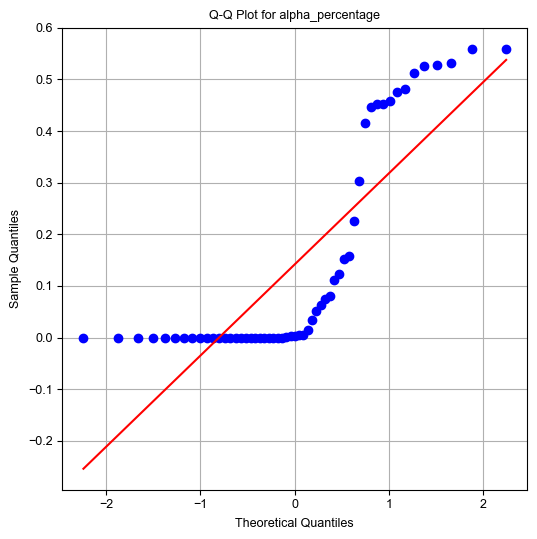

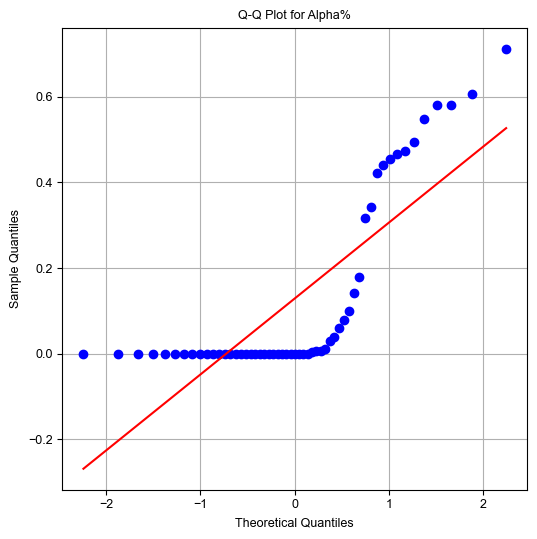

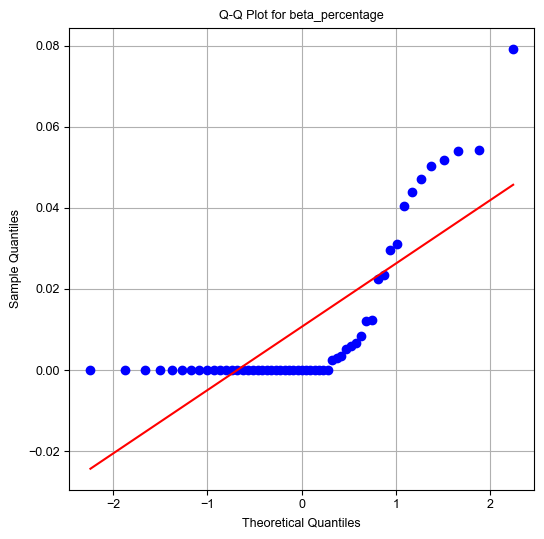

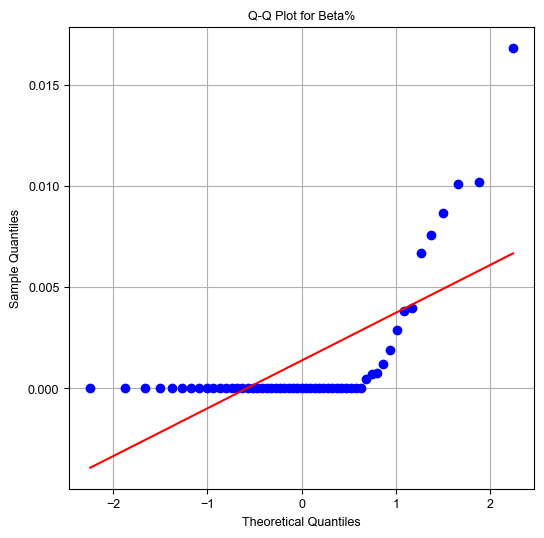

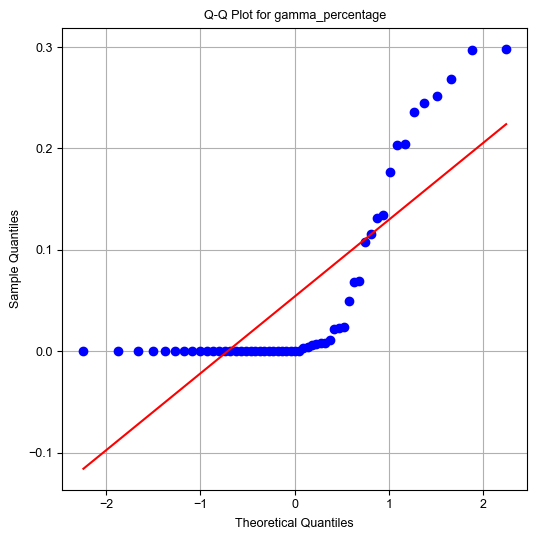

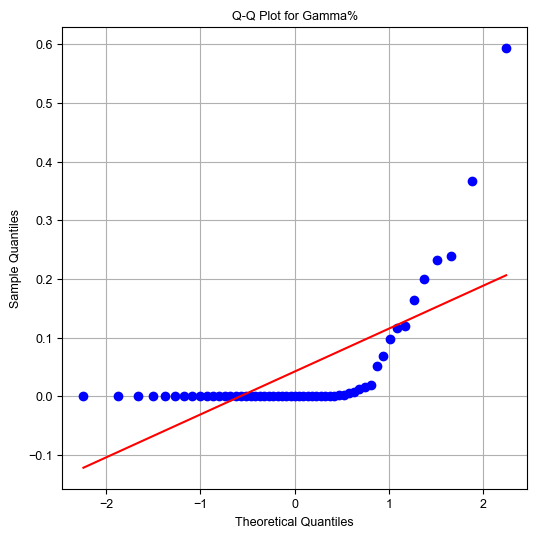

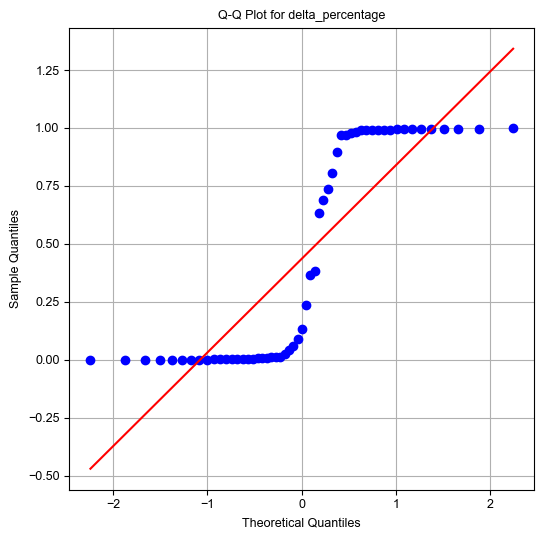

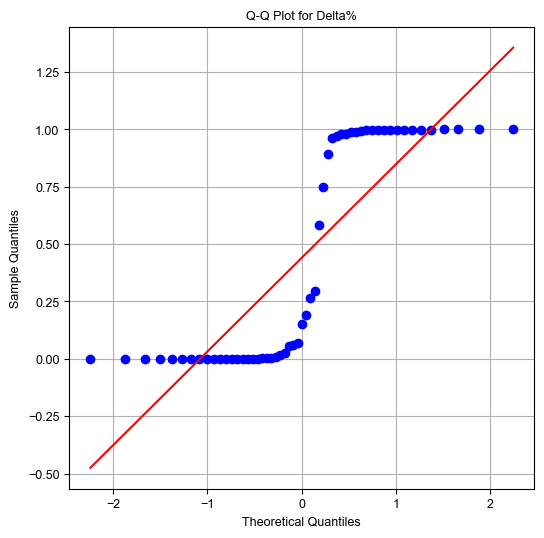

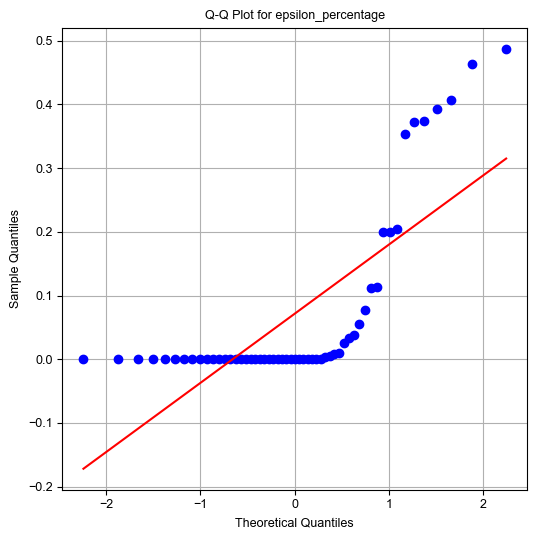

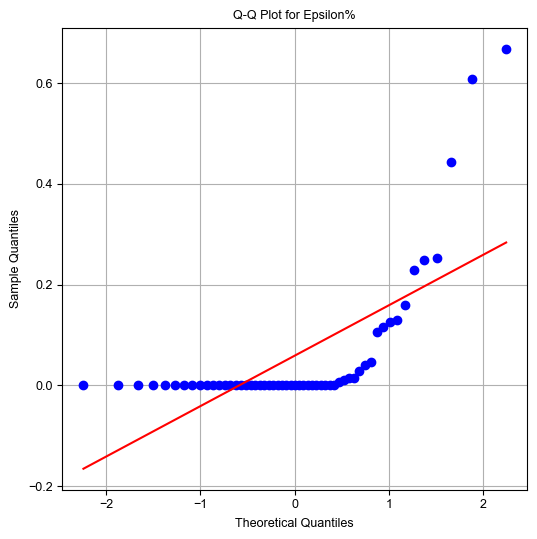

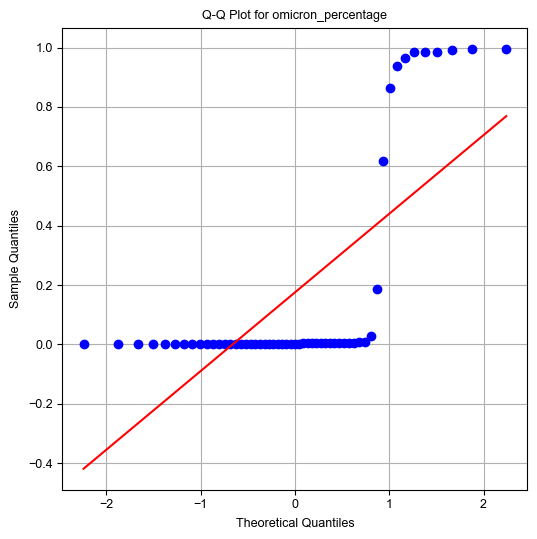

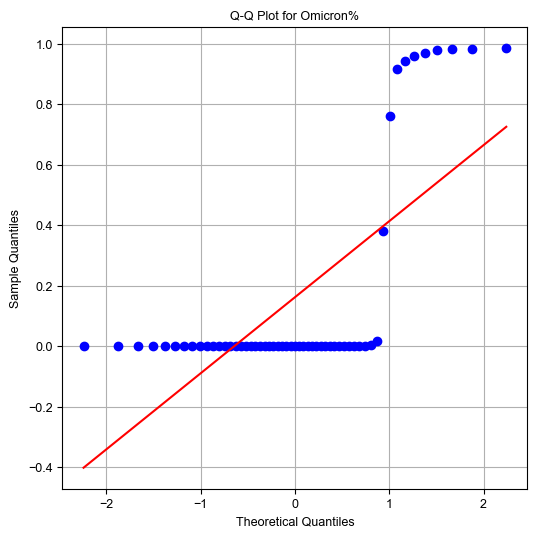

In [ ]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
cli_columns = ['alpha_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'epsilon_percentage', 'omicron_percentage']
ww_columns = ['Alpha%', 'Beta%', 'Gamma%', 'Delta%', 'Epsilon%', 'Omicron%']

# Define a function to create Q-Q plot
def qq_plot(data, title):
    plt.figure(figsize=(6, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.show()

# Create Q-Q plots for each column
for cli_col, ww_col in zip(cli_columns, ww_columns):
    qq_plot(combined_study_cleandf[cli_col], title=f"Q-Q Plot for {cli_col}")
    qq_plot(combined_study_cleandf[ww_col], title=f"Q-Q Plot for {ww_col}")


## Figure 3 Manuscript ( Time series and Correlation plot) Freyja vs Clinical Variants

/tmp/ipykernel_2513/4231877970.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_study_df['date'] = pd.to_datetime(combined_study_df['date'])
/tmp/ipykernel_2513/4231877970.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_study_df['Epiweek Number'] = combined_study_df['Epiweek Number'].astype(int)


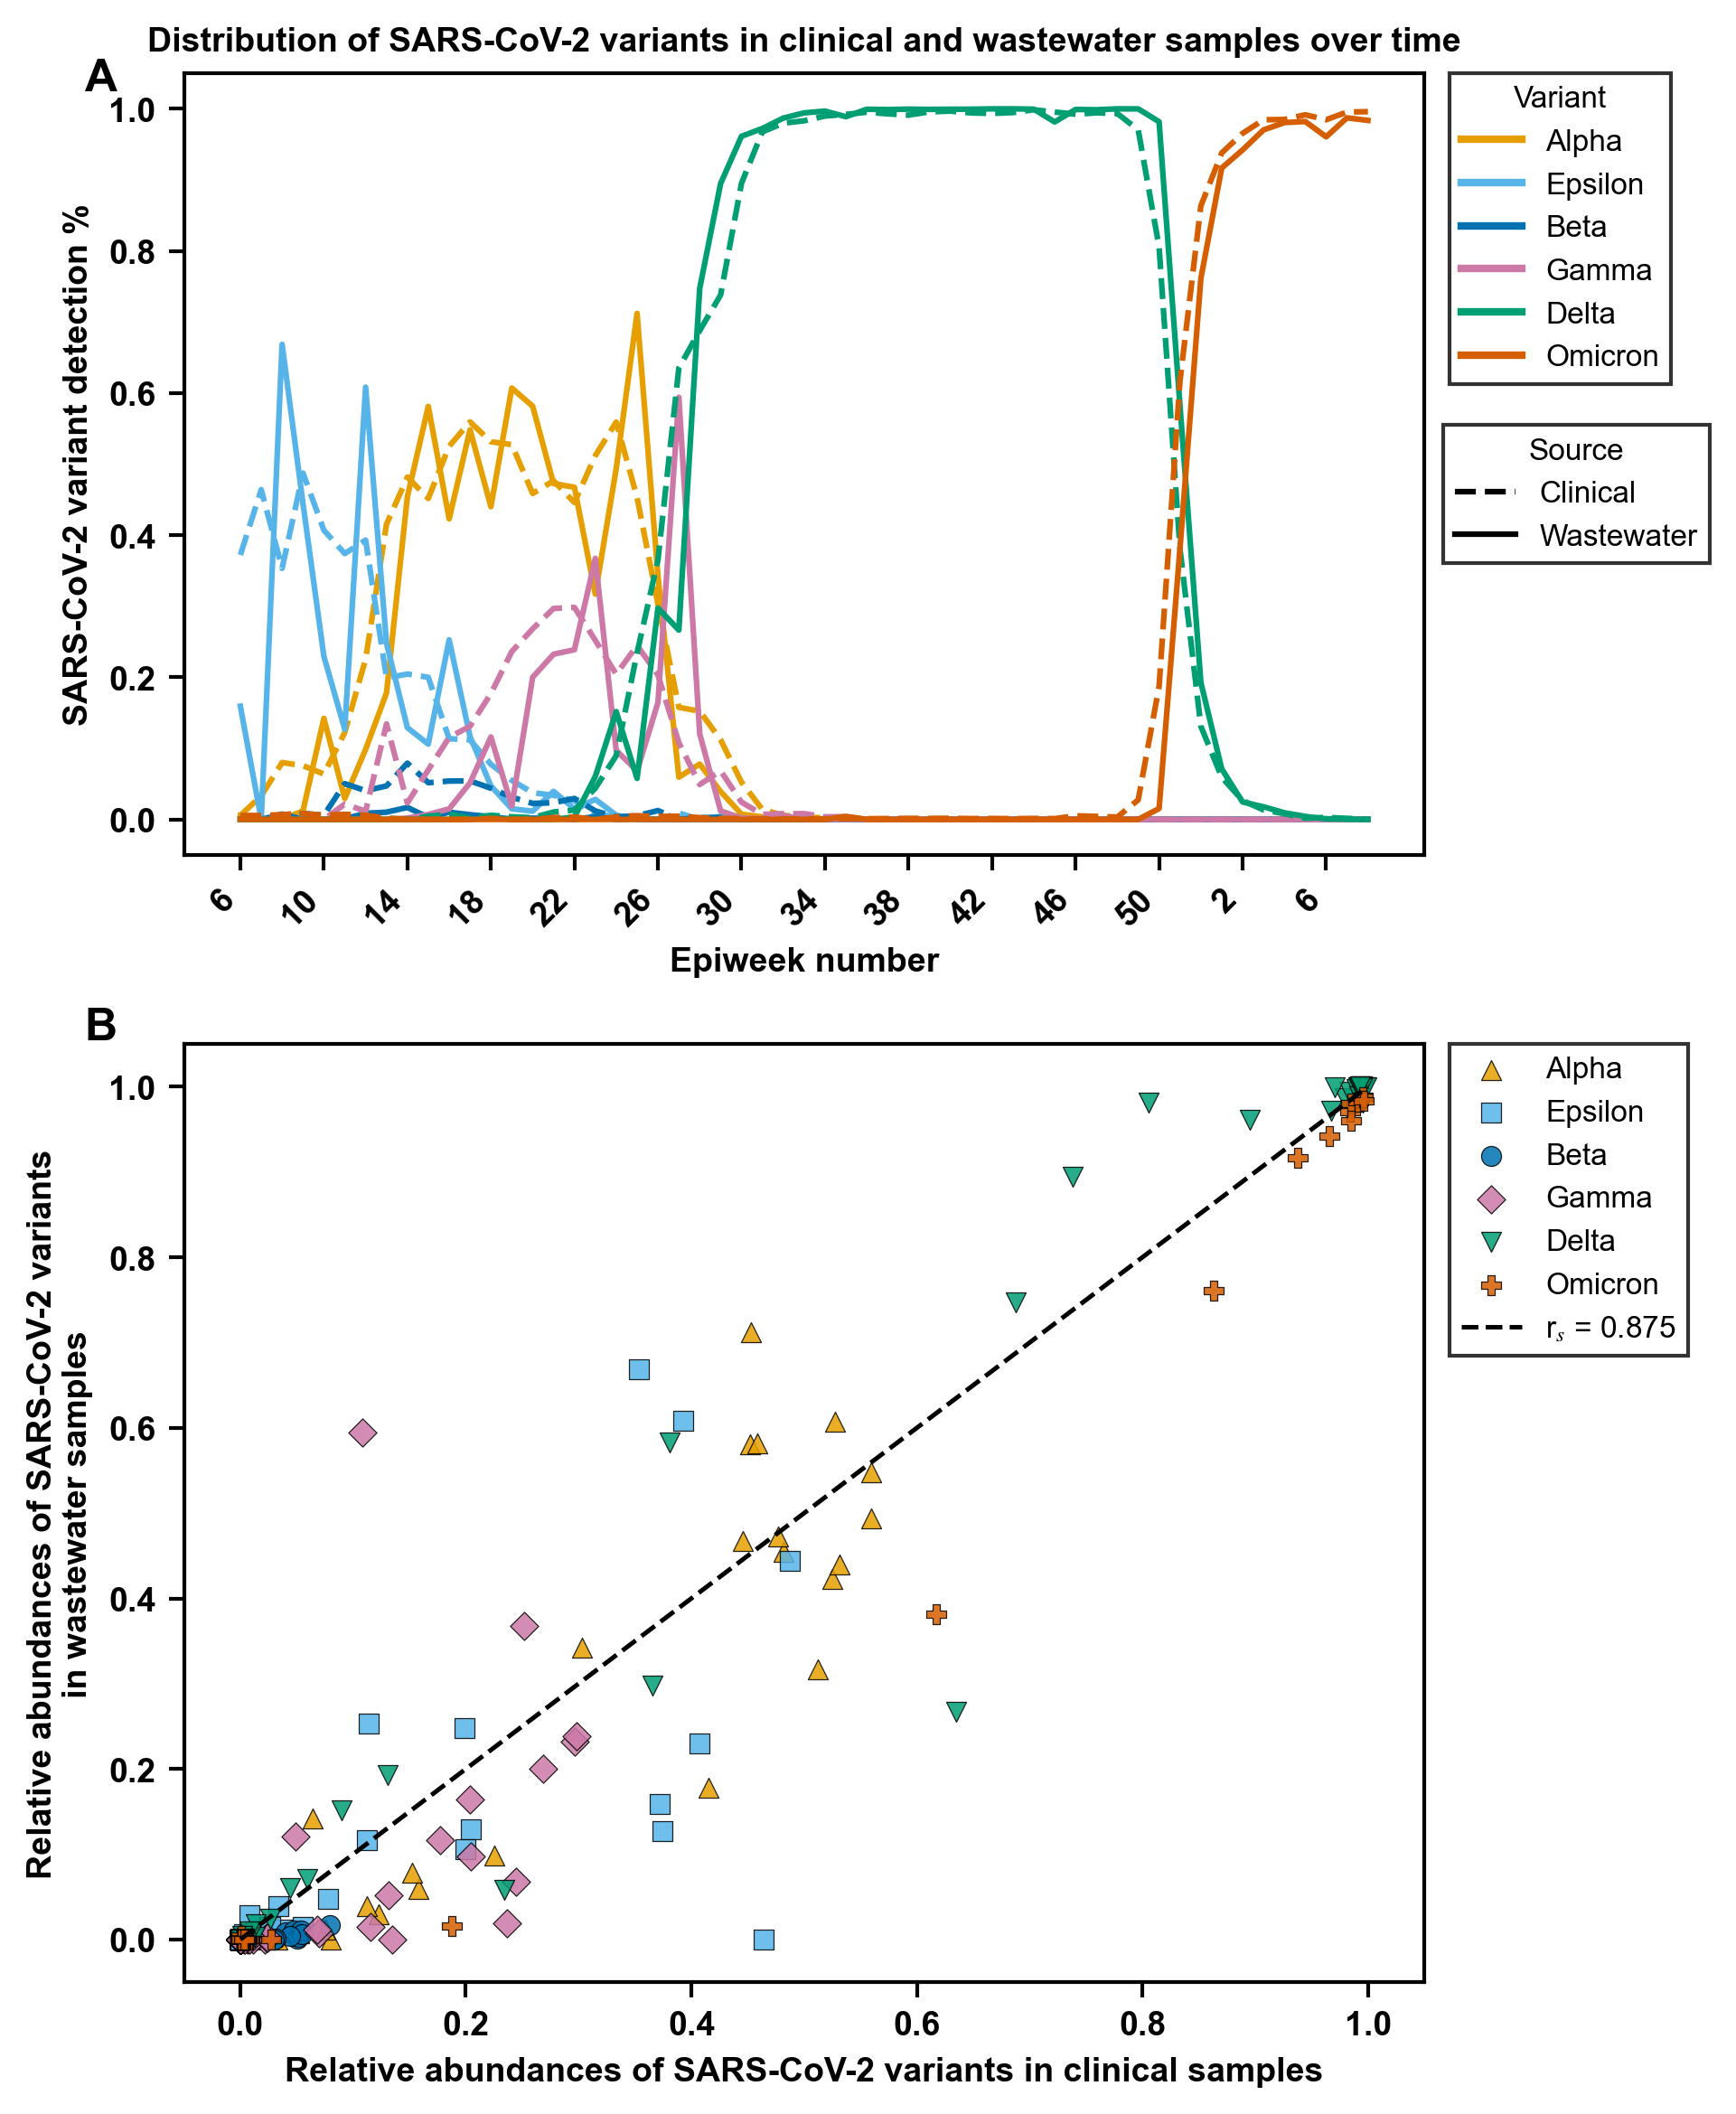

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib import font_manager

# FONT SETTINGS FOR PLOS ONE
available_fonts = [f.name for f in font_manager.fontManager.ttflist]

if 'Arial' in available_fonts:
    chosen_font = 'Arial'
elif 'Times New Roman' in available_fonts:
    chosen_font = 'Times New Roman'
else:
    chosen_font = 'Times'

plt.rcParams.update({
    'font.family': chosen_font,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'mathtext.fontset': 'stix'
})

# DEFINE VARIANTS, COLUMNS, AND COLORS
cli_columns = ['alpha_percentage', 'epsilon_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'omicron_percentage']
ww_columns = ['Alpha%', 'Epsilon%', 'Beta%', 'Gamma%', 'Delta%', 'Omicron%']
variant_names = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']

color_map = {
    'Alpha': '#E69F00',
    'Epsilon': '#56B4E9',
    'Beta': '#0072B2',
    'Gamma': '#CC79A7',
    'Delta': '#009E73',
    'Omicron': '#D55E00'
}

marker_map = {
    'Alpha': '^',
    'Epsilon': 's',
    'Beta': 'o',
    'Gamma': 'D',
    'Delta': 'v',
    'Omicron': 'P'
}

# PREP DATA
combined_study_df['date'] = pd.to_datetime(combined_study_df['date'])
combined_study_df['Epiweek Number'] = combined_study_df['Epiweek Number'].astype(int)

# CREATE PANEL FIGURE
fig, axes = plt.subplots(
    2, 1,
    figsize=(7.5, 8),
    dpi=300,
    gridspec_kw={'height_ratios': [1.00, 1.20]}
)

ax1 = axes[0]
ax2 = axes[1]

# FIGURE 3A: VARIANT DISTRIBUTION OVER TIME

for cli_col, ww_col, name in zip(cli_columns, ww_columns, variant_names):

    color = color_map[name]

    ax1.plot(
        combined_study_df['date'],
        combined_study_df[cli_col],
        linestyle='--',
        linewidth=1.5,
        color=color
    )

    ax1.plot(
        combined_study_df['date'],
        combined_study_df[ww_col],
        linestyle='-',
        linewidth=1.5,
        color=color
    )

epiweek_filter = (combined_study_df['Epiweek Number'] - 6) % 4 == 0
filtered_dates = combined_study_df.loc[epiweek_filter, 'date']
filtered_epiweeks = combined_study_df.loc[epiweek_filter, 'Epiweek Number']

ax1.set_xticks(filtered_dates)
ax1.set_xticklabels(filtered_epiweeks, rotation=45, ha='right')

ax1.set_xlabel('Epiweek number', fontweight='bold')
ax1.set_ylabel('SARS-CoV-2 variant detection %', fontweight='bold')
ax1.set_title(
    'Distribution of SARS-CoV-2 variants in clinical and wastewater samples over time',
    fontweight='bold',
    pad=6
)

ax1.text(
    -0.08, 1.02, 'A',
    transform=ax1.transAxes,
    fontsize=12,
    fontweight='bold',
    va='top',
    ha='left'
)

variant_handles = [
    Line2D([0], [0], color=color_map[name], lw=2, label=name)
    for name in variant_names
]

legend1 = ax1.legend(
    handles=variant_handles,
    title='Variant',
    title_fontsize=8,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

ax1.add_artist(legend1)

source_handles = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='Clinical'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Wastewater')
]

ax1.legend(
    handles=source_handles,
    title='Source',
    title_fontsize=8,
    loc='upper right',
    bbox_to_anchor=(1.23, 0.55),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

# FIGURE 3B: CLINICAL VS WASTEWATER CORRELATION

all_cli_data = pd.Series(dtype=float)
all_ww_data = pd.Series(dtype=float)

for cli_col, ww_col, name in zip(cli_columns, ww_columns, variant_names):

    valid_df = combined_study_cleandf[[cli_col, ww_col]].dropna()
    X = valid_df[cli_col]
    y = valid_df[ww_col]

    color = color_map[name]
    marker = marker_map[name]

    ax2.scatter(
        X,
        y,
        color=color,
        marker=marker,
        s=28,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.3,
        label=name
    )

    all_cli_data = pd.concat([all_cli_data, X])
    all_ww_data = pd.concat([all_ww_data, y])

overall_spearman, overall_spearman_p = spearmanr(all_cli_data, all_ww_data)

# IDENTITY LINE

ax2.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--',
    linewidth=1.2,
    label=f'r$_s$ = {overall_spearman:.3f}'
)

ax2.set_xlabel(
    'Relative abundances of SARS-CoV-2 variants in clinical samples',
    fontweight='bold'
)

ax2.set_ylabel(
    'Relative abundances of SARS-CoV-2 variants\nin wastewater samples',
    fontweight='bold'
)

ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)

ax2.text(
    -0.08, 1.04, 'B',
    transform=ax2.transAxes,
    fontsize=12,
    fontweight='bold',
    va='top',
    ha='left'
)

ax2.legend(
    loc='upper left',
    bbox_to_anchor=(1.02,1.00),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

# MAKE ALL TICKS, TITLES, LABELS BOLD

for ax in [ax1, ax2]:

    ax.tick_params(axis='both', which='major', labelsize=9, width=1, length=4)

    for tick in ax.get_xticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    for tick in ax.get_yticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    ax.xaxis.label.set_fontname(chosen_font)
    ax.xaxis.label.set_fontweight('bold')

    ax.yaxis.label.set_fontname(chosen_font)
    ax.yaxis.label.set_fontweight('bold')

    ax.title.set_fontname(chosen_font)
    ax.title.set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_linewidth(1)

# FINAL LAYOUT

plt.subplots_adjust(
    left=0.17,
    right=0.78,
    top=0.96,
    bottom=0.08,
    hspace=0.22
)

plt.savefig(FIG3_PNG, dpi=300)
save_plos_tiff(plt.gcf(), FIG3_TIFF)

plt.show()



##MLST study Correlation with clinical variants

In [ ]:
gisaid_df = gisaid_df.drop(columns=['freq_alpha', 'freq_beta', 'freq_gamma', 'freq_epsilon', 'freq_delta', 'freq','freq_omicron', 'total_6_variants','percentage_of_6_variants','other_variants' ])
gisaid_df

,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage
0,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556
1,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525
2,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667
3,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403
4,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814
5,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194
6,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780
7,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745
8,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000
9,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000


##Import MLST Lineage Relative Abundances

In [ ]:
path_ww = MLST_INPUT
ww_df = pd.read_excel(path_ww)
ww_df


,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon
0,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
ww_df['Start_date'] = gisaid_df['date']
ww_df

,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Start_date
0,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,2021-02-07
1,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,2021-02-14
2,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,2021-02-21
3,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,2021-02-28
4,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,2021-03-07
5,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,2021-03-14
6,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,2021-03-21
7,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,2021-03-28
8,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,2021-04-04
9,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,2021-04-11


In [ ]:
combined_study_df = pd.merge(gisaid_df, ww_df , left_on='date', right_on='Start_date', how='outer')

combined_study_df


,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Start_date
0,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,2021-02-07
1,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,2021-02-14
2,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,2021-02-21
3,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,2021-02-28
4,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,2021-03-07
5,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,2021-03-14
6,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,2021-03-21
7,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,2021-03-28
8,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,2021-04-04
9,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,2021-04-11


In [ ]:
combined_study_df.drop(columns=['Start_date'], inplace=True)
column_order = ['MMWR'] + [col for col in combined_study_df if col != 'MMWR']
combined_study_df = combined_study_df[column_order]
combined_study_df

,MMWR,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Alpha,Beta,Gamma,Delta,Omicron,Epsilon
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
# Column names to append "_MLST" to
columns_to_rename = ['Alpha', 'Beta', 'Gamma', 'Delta', 'Omicron', 'Epsilon']

# Building the dictionary for renaming
rename_dict = {col: f"{col}_MLST" for col in columns_to_rename}

# Rename the columns in combined_study_df
combined_study_df = combined_study_df.rename(columns=rename_dict)

# Display the updated DataFrame to verify the changes
combined_study_df


,MMWR,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Alpha_MLST,Beta_MLST,Gamma_MLST,Delta_MLST,Omicron_MLST,Epsilon_MLST
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
combined_study_df = combined_study_df.dropna()
combined_study_df

,MMWR,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Alpha_MLST,Beta_MLST,Gamma_MLST,Delta_MLST,Omicron_MLST,Epsilon_MLST
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
combined_study_df = combined_study_df.dropna()
combined_study_df

,MMWR,date,alpha_percentage,beta_percentage,delta_percentage,epsilon_percentage,gamma_percentage,omicron_percentage,Alpha_MLST,Beta_MLST,Gamma_MLST,Delta_MLST,Omicron_MLST,Epsilon_MLST
0,6,2021-02-07,0.005556,0.000000,0.000000,0.372222,0.000000,0.005556,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,2021-02-14,0.033149,0.000000,0.000000,0.464088,0.000000,0.005525,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,2021-02-21,0.080000,0.006667,0.000000,0.353333,0.006667,0.006667,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,2021-02-28,0.075630,0.008403,0.000000,0.487395,0.000000,0.008403,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,2021-03-07,0.063953,0.005814,0.000000,0.406977,0.000000,0.005814,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,2021-03-14,0.122302,0.050360,0.000000,0.374101,0.021583,0.007194,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,2021-03-21,0.225434,0.040462,0.000000,0.393064,0.011561,0.005780,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,2021-03-28,0.415358,0.047120,0.001745,0.198953,0.134380,0.001745,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,2021-04-04,0.481848,0.079208,0.000000,0.204620,0.023102,0.000000,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,2021-04-11,0.451685,0.051685,0.004494,0.200000,0.069663,0.000000,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
combined_study_df.to_excel(COMBINED_RA_MLST_PATH)
print(f"Saved: {COMBINED_RA_MLST_PATH}")


Saved: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Combined_relative_abundance/combined_relative_abundances_MLST.xlsx


In [ ]:
cli_columns = ['alpha_percentage', 'beta_percentage', 'gamma_percentage', 'delta_percentage', 'epsilon_percentage', 'omicron_percentage']
ww_columns = ['Alpha_MLST', 'Beta_MLST', 'Gamma_MLST', 'Delta_MLST', 'Epsilon_MLST', 'Omicron_MLST']


In [ ]:
from scipy.stats import shapiro
for cli_col, ww_col in zip(cli_columns, ww_columns):
    stat_cli, p_cli = shapiro(combined_study_df[cli_col])
    print(f"Shapiro-Wilk Test for {cli_col}:{stat_cli}")

    print(f"   p-value: {p_cli}")

    if p_cli < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

    stat_ww, p_ww = shapiro(combined_study_df[ww_col])
    print(f"Shapiro-Wilk Test for {ww_col}:{stat_ww}")
    print(f"   p-value: {p_ww}")

    if p_ww < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

Shapiro-Wilk Test for alpha_percentage:0.6859394795828162
   p-value: 1.4583473375249503e-09
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Alpha_MLST:0.6554619452188664
   p-value: 4.2620067594086526e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for beta_percentage:0.6218906528046804
   p-value: 1.192487224032426e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Beta_MLST:0.5418942223258618
   p-value: 7.607545193874046e-12
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for gamma_percentage:0.6440011589815824
   p-value: 2.734388074116685e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Gamma_MLST:0.6924805606302191
   p-value: 1.9183837073727188e-09
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for delta_percentage:0.7199822668542274
   p-value: 6.345854657043969e-09
The combined data is not 

In [ ]:
# TABLE 2 (MLST HALF): CLINICAL VS MLST
# Circular block bootstrap confidence intervals

table2_mlst_df = prepare_dataframe(
    pd.read_excel(require_generated_file(TABLE2_MLST_PATH, 'Run the cell that saves COMBINED_RA_MLST_PATH before this Table 2 MLST cell.')),
    TABLE2_TIME,
    TABLE2_CLINICAL_COLUMNS + TABLE2_MLST_COLUMNS,
    'Table 2 MLST',
)

table2_mlst = calculate_table(
    df=table2_mlst_df,
    time_column=TABLE2_TIME,
    left_columns=TABLE2_CLINICAL_COLUMNS,
    right_columns=TABLE2_MLST_COLUMNS,
    variant_names=TABLE2_VARIANTS,
    seed=RANDOM_SEED + 20_000,
)

display(table2_mlst)


,Variant,Spearman_rs,CBB_95%_CI
0,All,0.812,0.688 - 0.900
1,Alpha,0.942,0.808 - 0.975
2,Epsilon,0.907,0.710 - 0.967
3,Beta,0.774,0.423 - 0.895
4,Gamma,0.875,0.652 - 0.958
5,Delta,0.818,0.457 - 0.931
6,Omicron,0.699,0.326 - 0.886


## Table 2: Statistical Assessment of SARS-CoV-2 Variant Relative Abundances of the MLST and Freyja Bioinformatic Approaches Between Wastewater and Clinical Samples.

In [ ]:
# TABLE 2: CLINICAL VS MLST AND CLINICAL VS FREYJA

table2_freyja_df = prepare_dataframe(
    pd.read_excel(require_generated_file(TABLE2_FREYJA_PATH, 'Run the cell that saves COMBINED_RA_FREYJA_PATH before this Table 2 Freyja cell.')),
    TABLE2_TIME,
    TABLE2_CLINICAL_COLUMNS + TABLE2_FREYJA_COLUMNS,
    'Table 2 Freyja',
)

table2_freyja = calculate_table(
    df=table2_freyja_df,
    time_column=TABLE2_TIME,
    left_columns=TABLE2_CLINICAL_COLUMNS,
    right_columns=TABLE2_FREYJA_COLUMNS,
    variant_names=TABLE2_VARIANTS,
    seed=RANDOM_SEED + 30_000,
)

table2 = pd.merge(
    table2_mlst,
    table2_freyja,
    on='Variant',
    suffixes=('_MLST', '_Freyja'),
)

table2 = table2[[
    'Variant',
    'Spearman_rs_MLST',
    'Spearman_rs_Freyja',
    'CBB_95%_CI_MLST',
    'CBB_95%_CI_Freyja',
]]

table2.to_csv(TABLE2_CSV, index=False)
print(f'Saved Table 2 CSV to: {TABLE2_CSV}')

display(table2)


Saved Table 2 CSV to: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Tables/Table2.csv


,Variant,Spearman_rs_MLST,Spearman_rs_Freyja,CBB_95%_CI_MLST,CBB_95%_CI_Freyja
0,All,0.812,0.875,0.688 - 0.900,0.813 - 0.918
1,Alpha,0.942,0.932,0.808 - 0.975,0.784 - 0.976
2,Epsilon,0.907,0.883,0.710 - 0.967,0.703 - 0.987
3,Beta,0.774,0.832,0.423 - 0.895,0.590 - 0.940
4,Gamma,0.875,0.873,0.652 - 0.958,0.650 - 0.962
5,Delta,0.818,0.943,0.457 - 0.931,0.804 - 0.976
6,Omicron,0.699,0.657,0.326 - 0.886,0.200 - 0.885


#Correlation between Old Pipeline results vs new

In [ ]:
path_wastewater_devrim = MLST_INPUT
ww_old_df = pd.read_excel(path_wastewater_devrim)
ww_old_df


,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon
0,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306
1,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338
2,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043
3,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097
4,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840
5,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245
6,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761
7,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086
8,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455
9,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128


In [ ]:
combined_wastewater_df = pd.concat([ww_old_df, lineages_df], axis = 1)
combined_wastewater_df

,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Epiweek Number,Start_Date,gc/d_sum,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,6.0,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,6,2021-02-07,1.436577e+13,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,7.0,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,7,2021-02-14,4.031267e+11,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,8.0,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,8,2021-02-21,4.903644e+12,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,9.0,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,9,2021-02-28,1.686143e+13,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,10.0,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,10,2021-03-07,2.154243e+13,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,11.0,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,11,2021-03-14,1.752764e+13,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,12.0,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,12,2021-03-21,2.020958e+13,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,13.0,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,13,2021-03-28,2.184643e+13,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,14.0,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,14,2021-04-04,4.114500e+13,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,15.0,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,15,2021-04-11,4.475415e+13,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
combined_wastewater_df= combined_wastewater_df.dropna()
combined_wastewater_df

,MMWR,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Epiweek Number,Start_Date,gc/d_sum,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,6.0,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,6,2021-02-07,1.436577e+13,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,7.0,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,7,2021-02-14,4.031267e+11,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,8.0,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,8,2021-02-21,4.903644e+12,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,9.0,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,9,2021-02-28,1.686143e+13,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,10.0,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,10,2021-03-07,2.154243e+13,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,11.0,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,11,2021-03-14,1.752764e+13,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,12.0,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,12,2021-03-21,2.020958e+13,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,13.0,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,13,2021-03-28,2.184643e+13,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,14.0,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,14,2021-04-04,4.114500e+13,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,15.0,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,15,2021-04-11,4.475415e+13,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
combined_wastewater_df.drop(columns=['MMWR'], inplace=True)
combined_wastewater_df

/tmp/ipykernel_2513/3423216063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_wastewater_df.drop(columns=['MMWR'], inplace=True)


,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Epiweek Number,Start_Date,gc/d_sum,Omicron_gc/d_sum,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,6,2021-02-07,1.436577e+13,0.000000e+00,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,7,2021-02-14,4.031267e+11,0.000000e+00,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,8,2021-02-21,4.903644e+12,0.000000e+00,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,9,2021-02-28,1.686143e+13,0.000000e+00,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,10,2021-03-07,2.154243e+13,0.000000e+00,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,11,2021-03-14,1.752764e+13,0.000000e+00,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,12,2021-03-21,2.020958e+13,0.000000e+00,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,13,2021-03-28,2.184643e+13,0.000000e+00,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,14,2021-04-04,4.114500e+13,0.000000e+00,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,15,2021-04-11,4.475415e+13,0.000000e+00,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
#column_order = [ 'Start_Date', 'Epiweek Number', 'Alpha', 'Alpha_gc/d', 'Beta', 'Beta_gc/d', 'Gamma', 'Gamma_gc/d', 'Delta', 'Delta_gc/d', 'Epsilon', 'Epsilon_gc/d', 'Omicron', 'Omicron_gc/d'] + [col for col in combined_wastewater_df.columns if col not in [ 'Start_Date', 'Epiweek Number', 'Alpha', 'Alpha_gc/d', 'Beta', 'Beta_gc/d', 'Gamma', 'Gamma_gc/d', 'Delta', 'Delta_gc/d', 'Epsilon', 'Epsilon_gc/d', 'Omicron', 'Omicron_gc/d']]
column_order = [ 'Start_Date', 'Epiweek Number'] + [col for col in combined_wastewater_df.columns if col not in [ 'Start_Date', 'Epiweek Number']]

combined_wastewater_df = combined_wastewater_df[column_order]


In [ ]:
combined_wastewater_df

,Start_Date,Epiweek Number,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,gc/d_sum,Omicron_gc/d_sum,...,Recombinants_gc/d_sum,Others_gc/d_sum,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%,Recombinants%,Others%
0,2021-02-07,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,1.436577e+13,0.000000e+00,...,0.000000e+00,1.198764e+13,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331,0.000000,0.834459
1,2021-02-14,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,4.031267e+11,0.000000e+00,...,0.000000e+00,4.021455e+11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.997566
2,2021-02-21,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,4.903644e+12,0.000000e+00,...,0.000000e+00,1.545609e+12,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577,0.000000,0.315196
3,2021-02-28,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,1.686143e+13,0.000000e+00,...,0.000000e+00,9.069289e+12,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452,0.000000,0.537872
4,2021-03-07,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,2.154243e+13,0.000000e+00,...,0.000000e+00,1.346376e+13,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706,0.000000,0.624988
5,2021-03-14,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,1.752764e+13,0.000000e+00,...,0.000000e+00,1.466402e+13,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761,0.000000,0.836623
6,2021-03-21,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,2.020958e+13,0.000000e+00,...,0.000000e+00,5.701423e+12,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287,0.000000,0.282115
7,2021-03-28,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,2.184643e+13,0.000000e+00,...,0.000000e+00,1.229889e+13,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047,0.000000,0.562970
8,2021-04-04,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,4.114500e+13,0.000000e+00,...,3.058634e+10,1.579452e+13,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105,0.000743,0.383875
9,2021-04-11,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,4.475415e+13,0.000000e+00,...,3.064515e+10,1.339980e+13,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897,0.000685,0.299409


In [ ]:
columns_to_drop = ['Omicron_gc/d_sum', 'Recombinants_gc/d_sum', 'Others_gc/d_sum', 'Alpha_gc/d_sum', 'gc/d_sum', 'Beta_gc/d_sum', 'Delta_gc/d_sum', 'Gamma_gc/d_sum', 'Epsilon_gc/d_sum', 'Recombinants%', 'Others%']  # Add other column names as needed
combined_ww_cleandf = combined_wastewater_df.drop(columns=columns_to_drop)


In [ ]:
combined_ww_cleandf

,Start_Date,Epiweek Number,Alpha,Beta,Gamma,Delta,Omicron,Epsilon,Omicron%,Alpha%,Delta%,Beta%,Gamma%,Epsilon%
0,2021-02-07,6,0.000000,0.000000,0.085557,0.170754,0.000000,0.421306,0.000000,0.005603,0.000000,0.000000,0.000000,0.159331
1,2021-02-14,7,0.000969,0.000000,0.081256,0.131594,0.000000,0.273338,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2021-02-21,8,0.003753,0.000000,0.086041,0.104878,0.000000,0.533043,0.000000,0.000000,0.000000,0.007569,0.000000,0.668577
3,2021-02-28,9,0.015409,0.000000,0.100687,0.104474,0.000000,0.157097,0.000000,0.012052,0.000000,0.000000,0.000000,0.444452
4,2021-03-07,10,0.126362,0.003741,0.087198,0.145118,0.000000,0.316840,0.000000,0.142306,0.000000,0.000000,0.000000,0.229706
5,2021-03-14,11,0.029370,0.000776,0.086446,0.127828,0.000000,0.139245,0.000000,0.029443,0.000000,0.000788,0.000000,0.126761
6,2021-03-21,12,0.115700,0.008559,0.100228,0.155627,0.000000,0.584761,0.000000,0.098586,0.000000,0.008671,0.000000,0.608287
7,2021-03-28,13,0.202050,0.051538,0.203319,0.092817,0.000000,0.259086,0.000000,0.177980,0.000000,0.010204,0.000000,0.248047
8,2021-04-04,14,0.386940,0.020510,0.125833,0.096249,0.000000,0.203455,0.000000,0.454186,0.000000,0.016851,0.001951,0.129105
9,2021-04-11,15,0.496364,0.015040,0.148402,0.086164,0.000000,0.199128,0.000000,0.581216,0.000000,0.002881,0.006995,0.105897


In [ ]:
column_order_clean = [ 'Start_Date', 'Epiweek Number', 'Alpha', 'Alpha%', 'Beta', 'Beta%', 'Gamma', 'Gamma%', 'Delta', 'Delta%', 'Epsilon', 'Epsilon%', 'Omicron', 'Omicron%'] + [col for col in combined_ww_cleandf.columns if col not in [ 'Start_Date', 'Epiweek Number', 'Alpha', 'Alpha%', 'Beta', 'Beta%', 'Gamma', 'Gamma%', 'Delta', 'Delta%', 'Epsilon', 'Epsilon%', 'Omicron', 'Omicron%']]
combined_ww_cleandf = combined_ww_cleandf[column_order_clean]

In [ ]:
combined_ww_cleandf

,Start_Date,Epiweek Number,Alpha,Alpha%,Beta,Beta%,Gamma,Gamma%,Delta,Delta%,Epsilon,Epsilon%,Omicron,Omicron%
0,2021-02-07,6,0.000000,0.005603,0.000000,0.000000,0.085557,0.000000,0.170754,0.000000,0.421306,0.159331,0.000000,0.000000
1,2021-02-14,7,0.000969,0.000000,0.000000,0.000000,0.081256,0.000000,0.131594,0.000000,0.273338,0.000000,0.000000,0.000000
2,2021-02-21,8,0.003753,0.000000,0.000000,0.007569,0.086041,0.000000,0.104878,0.000000,0.533043,0.668577,0.000000,0.000000
3,2021-02-28,9,0.015409,0.012052,0.000000,0.000000,0.100687,0.000000,0.104474,0.000000,0.157097,0.444452,0.000000,0.000000
4,2021-03-07,10,0.126362,0.142306,0.003741,0.000000,0.087198,0.000000,0.145118,0.000000,0.316840,0.229706,0.000000,0.000000
5,2021-03-14,11,0.029370,0.029443,0.000776,0.000788,0.086446,0.000000,0.127828,0.000000,0.139245,0.126761,0.000000,0.000000
6,2021-03-21,12,0.115700,0.098586,0.008559,0.008671,0.100228,0.000000,0.155627,0.000000,0.584761,0.608287,0.000000,0.000000
7,2021-03-28,13,0.202050,0.177980,0.051538,0.010204,0.203319,0.000000,0.092817,0.000000,0.259086,0.248047,0.000000,0.000000
8,2021-04-04,14,0.386940,0.454186,0.020510,0.016851,0.125833,0.001951,0.096249,0.000000,0.203455,0.129105,0.000000,0.000000
9,2021-04-11,15,0.496364,0.581216,0.015040,0.002881,0.148402,0.006995,0.086164,0.000000,0.199128,0.105897,0.000000,0.000000


In [ ]:
combined_ww_cleandf.to_excel(COMBINED_WW_CLEAN_PATH)
print(f"Saved: {COMBINED_WW_CLEAN_PATH}")


Saved: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/FreyjaVSMLST/combined_ww_cleandf.xlsx


In [ ]:
old_columns = ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon', 'Omicron']    #MLST
new_columns = ['Alpha%', 'Beta%', 'Gamma%', 'Delta%', 'Epsilon%', 'Omicron%']  #Freyja


###Using concat () instead of append()

##Shapiro Test For both pipelines

In [ ]:
combined_ww_cleandf = combined_ww_cleandf.dropna()

In [ ]:
from scipy.stats import shapiro
for old_col, new_col in zip(old_columns, new_columns):
    stat_old, p_old = shapiro(combined_ww_cleandf[old_col])
    print(f"Shapiro-Wilk Test for {old_col}:{stat_old}")

    print(f"   p-value: {p_old}")

    if p_old < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

    stat_new, p_new = shapiro(combined_ww_cleandf[new_col])
    print(f"Shapiro-Wilk Test for {new_col}:{stat_new}")
    print(f"p-value: {p_new}")

    if p_new < 0.05:
          print("The combined data is not normally distributed (reject H0)")
    else:
          print("The combined data is normally distributed (fail to reject H0)")

Shapiro-Wilk Test for Alpha:0.6554619452188664
   p-value: 4.2620067594086526e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Alpha%:0.6456226322465679
p-value: 2.909888721521478e-10
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Beta:0.5418942223258618
   p-value: 7.607545193874046e-12
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Beta%:0.48480627418570954
p-value: 1.3009865322578458e-12
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Gamma:0.6924805606302191
   p-value: 1.9183837073727188e-09
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Gamma%:0.4649124676093561
p-value: 7.262354070417233e-13
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Delta:0.7477029486922475
   p-value: 2.293750410944307e-08
The combined data is not normally distributed (reject H0)
Shapiro-Wilk Test for Delta%:0.

##QQ Plot

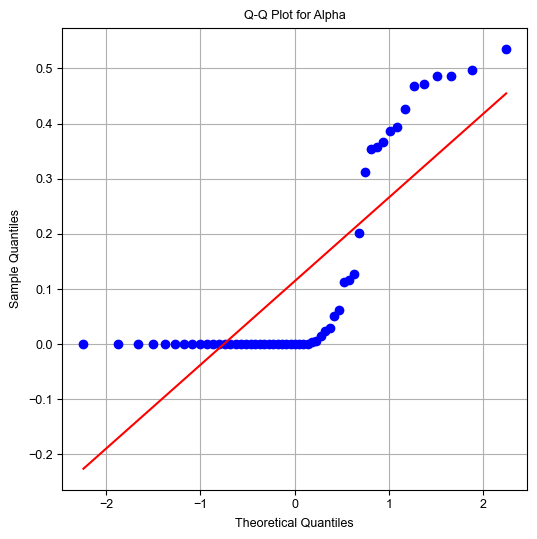

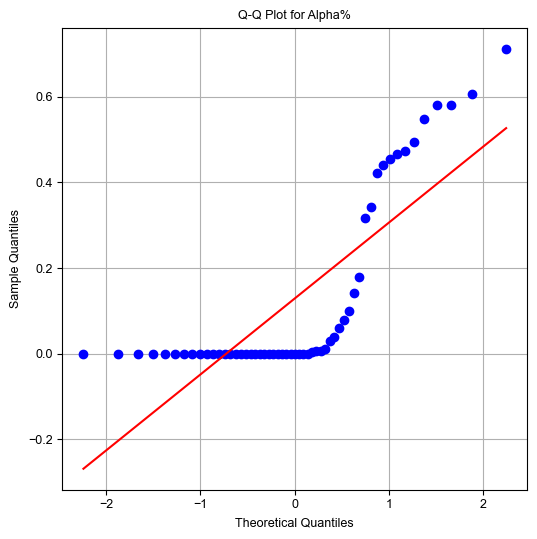

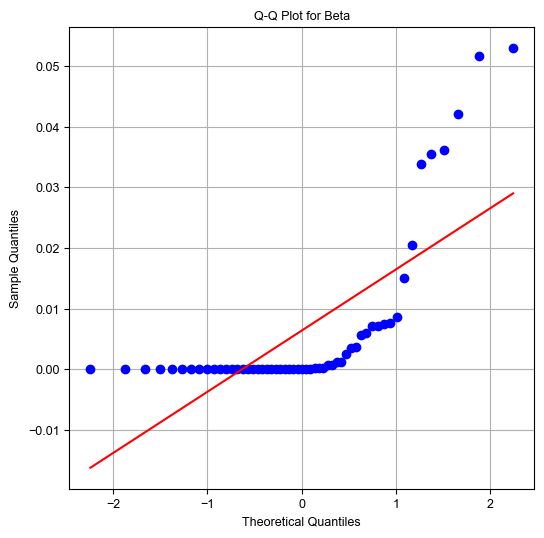

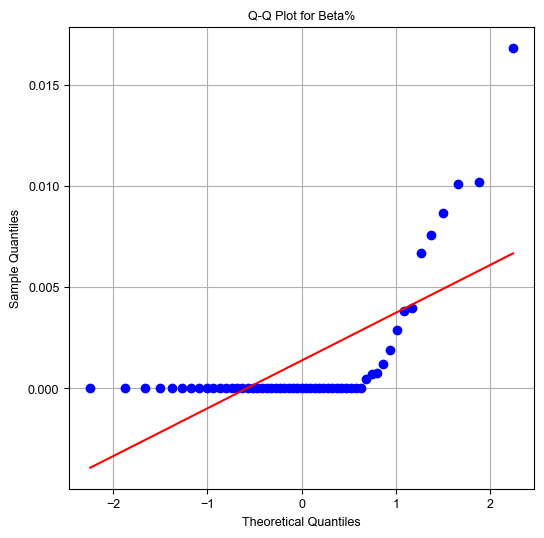

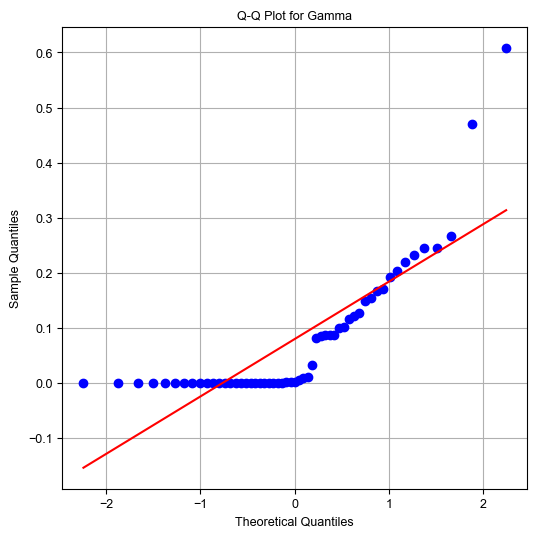

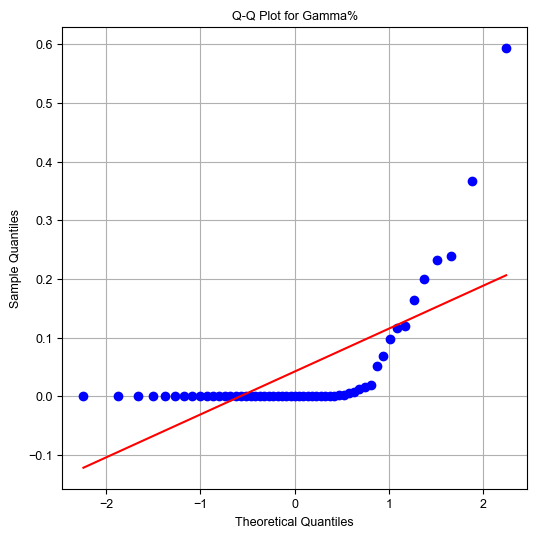

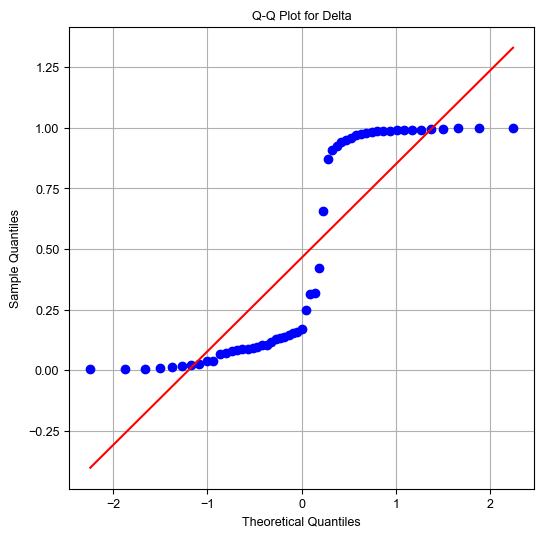

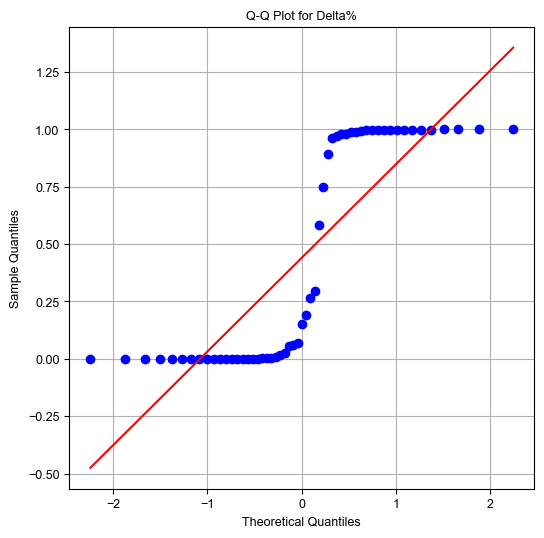

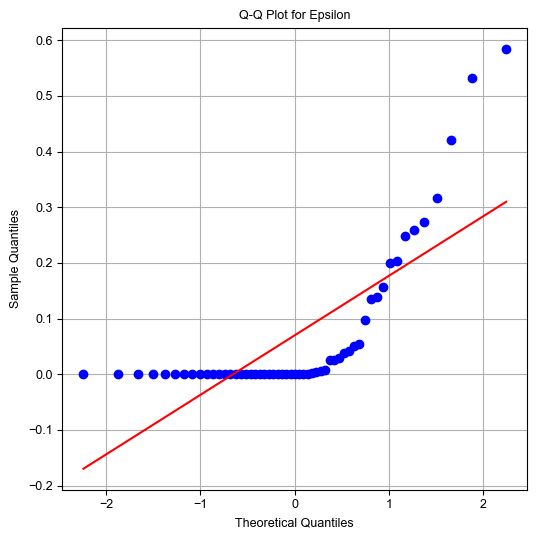

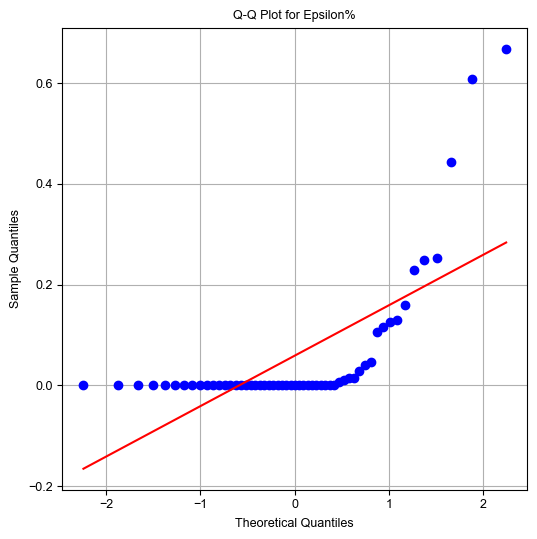

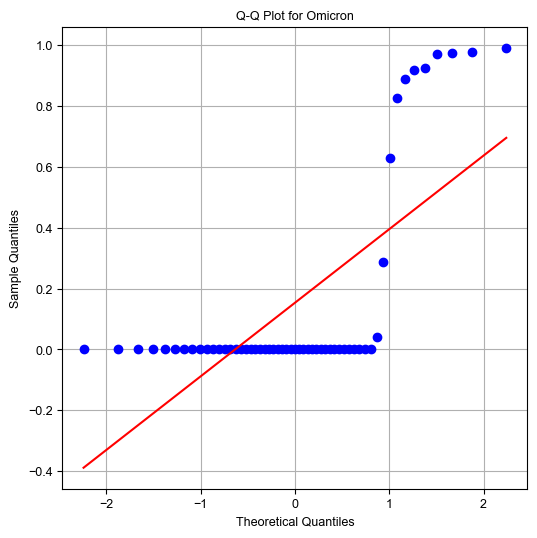

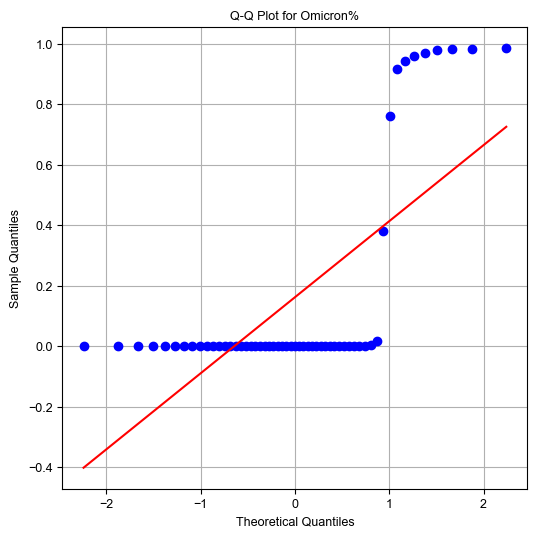

In [ ]:
# Define a function to create Q-Q plot
def qq_plot(data, title):
    plt.figure(figsize=(6, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.show()

# Create Q-Q plots for each column
for old_col, new_col in zip(old_columns, new_columns):
    qq_plot(combined_ww_cleandf[old_col], title=f"Q-Q Plot for {old_col}")
    qq_plot(combined_ww_cleandf[new_col], title=f"Q-Q Plot for {new_col}")

##Figure 4 Manuscript ( Time series and Correlation plot) Freyja vs MLST Variants

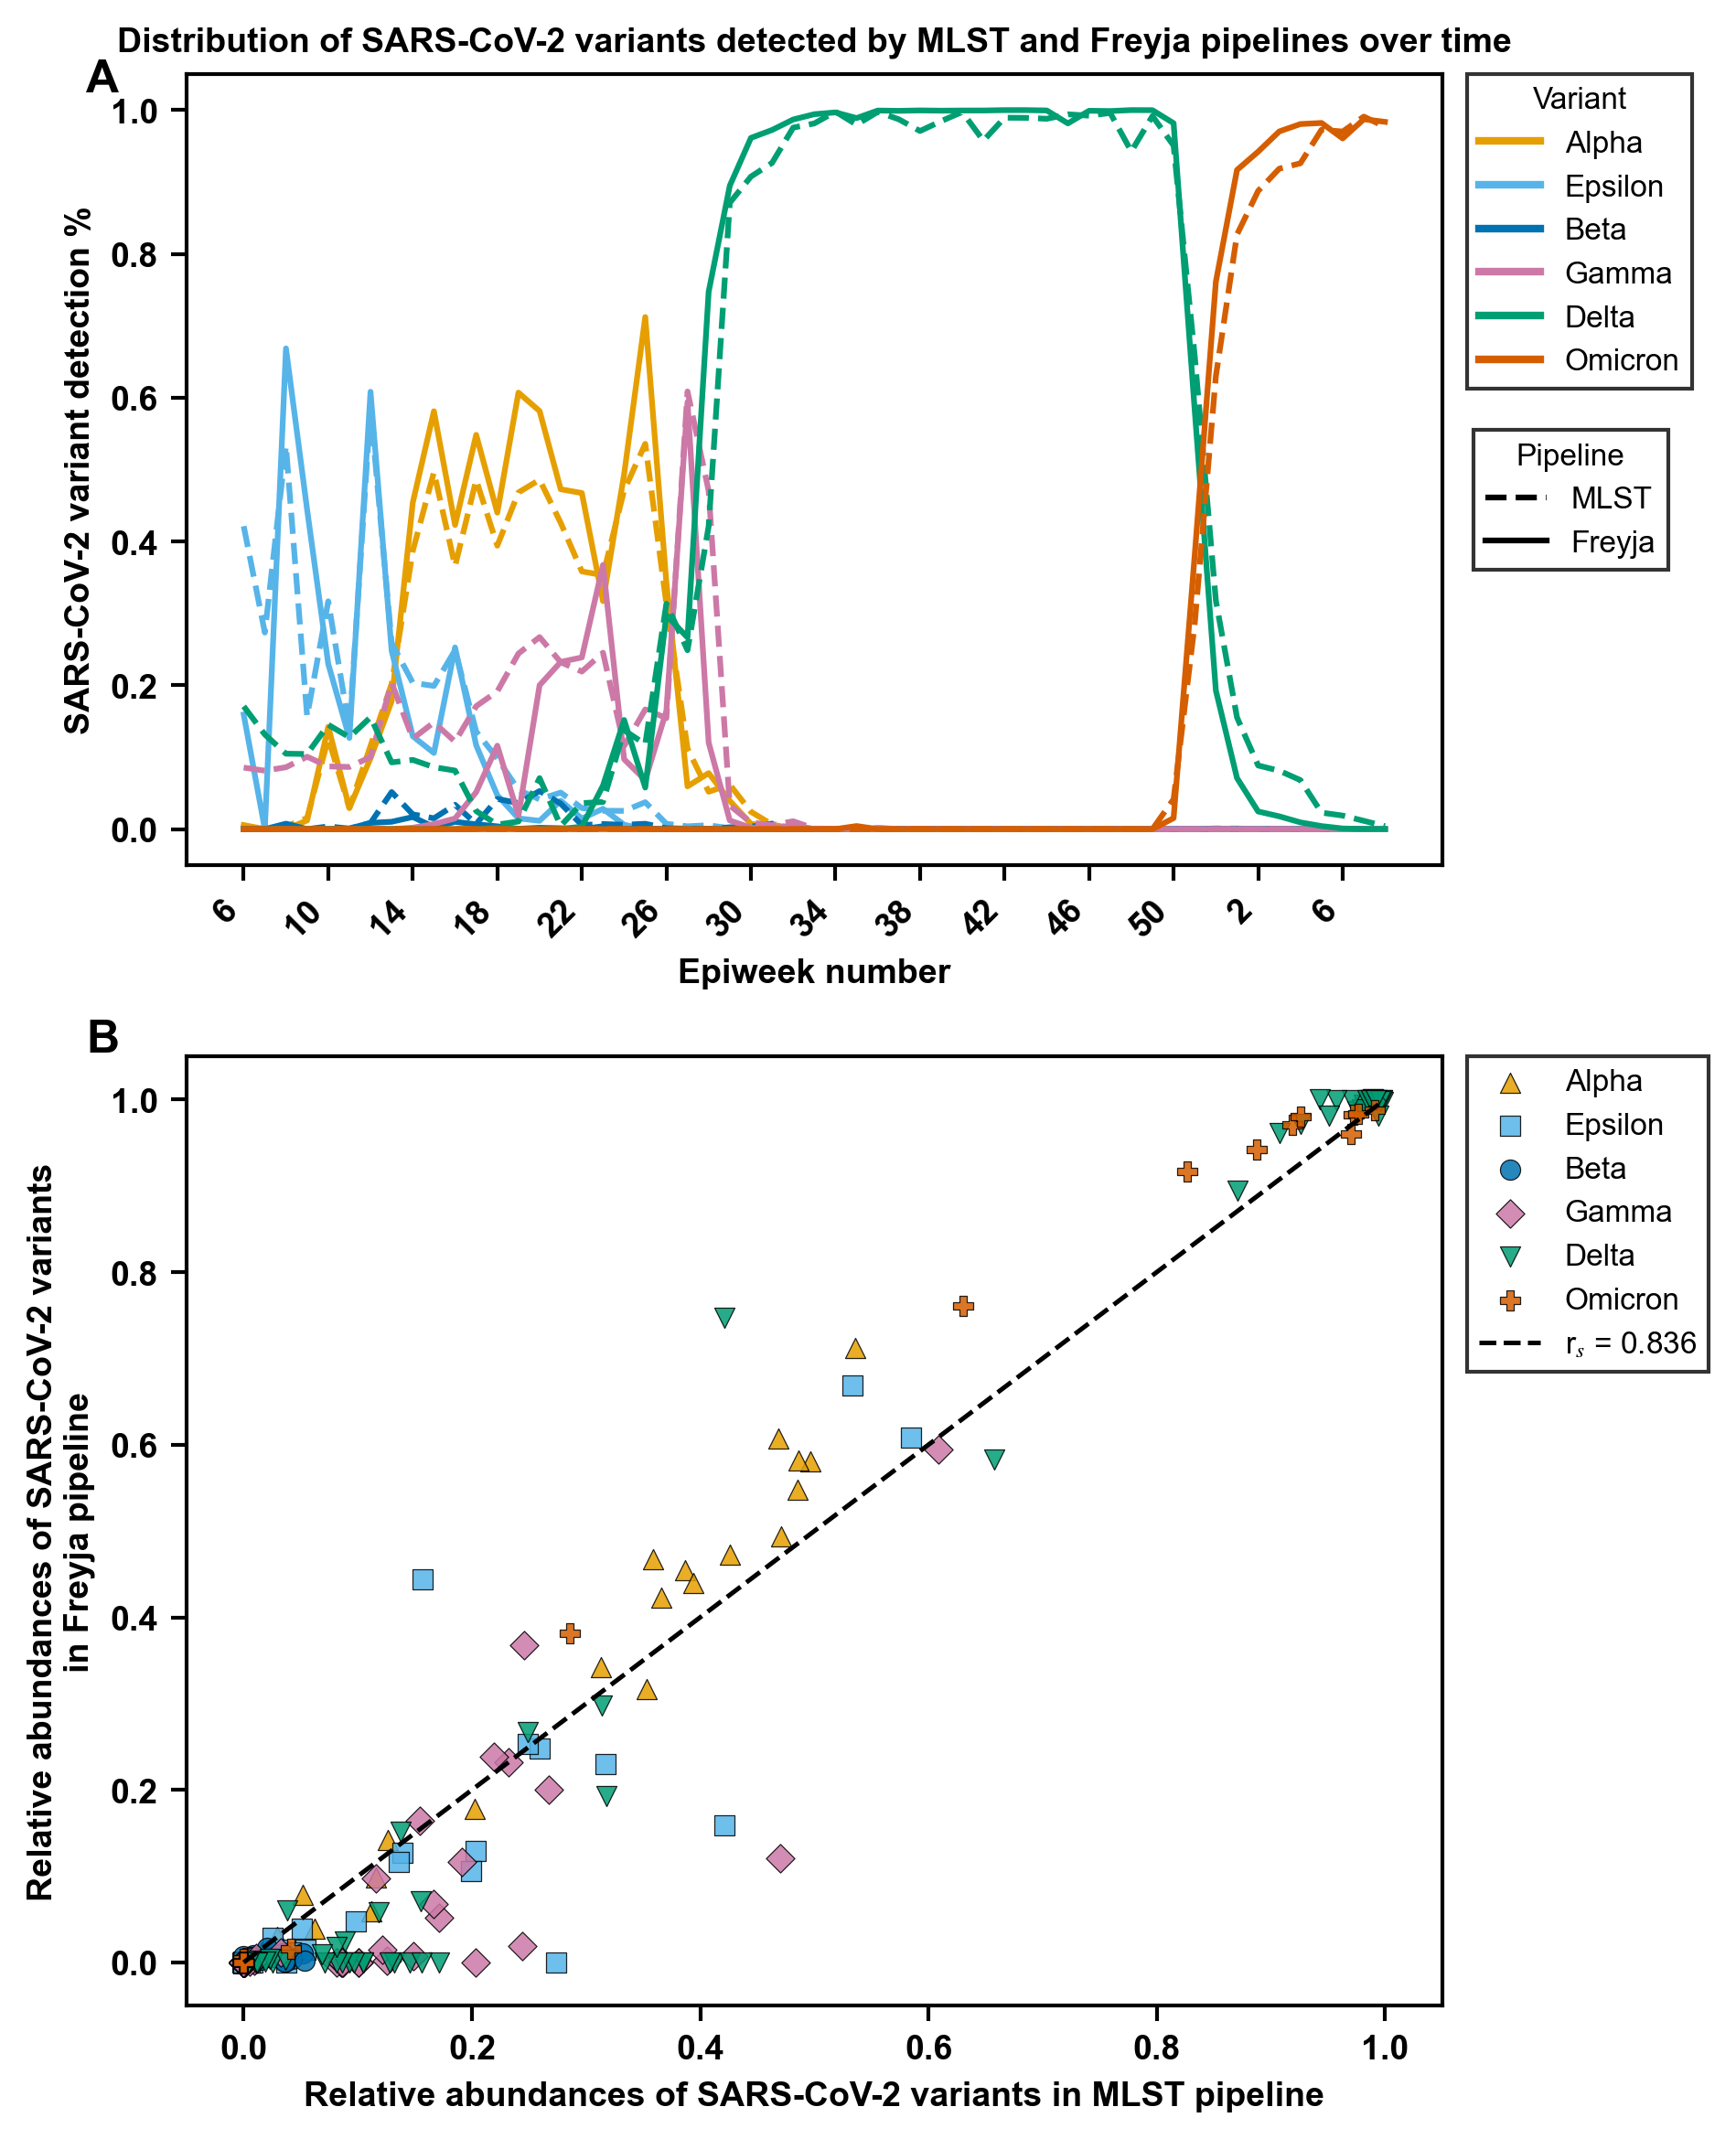

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from matplotlib.lines import Line2D
from matplotlib import font_manager

# FONT SETTINGS FOR PLOS ONE

available_fonts = [f.name for f in font_manager.fontManager.ttflist]

if 'Arial' in available_fonts:
    chosen_font = 'Arial'
elif 'Times New Roman' in available_fonts:
    chosen_font = 'Times New Roman'
else:
    chosen_font = 'Times'

plt.rcParams.update({
    'font.family': chosen_font,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
    'mathtext.fontset': 'stix'
})

# DEFINE COLUMNS AND COLORS

old_columns = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']
new_columns = ['Alpha%', 'Epsilon%', 'Beta%', 'Gamma%', 'Delta%', 'Omicron%']
variant_names = ['Alpha', 'Epsilon', 'Beta', 'Gamma', 'Delta', 'Omicron']

color_map = {
    'Alpha': '#E69F00',
    'Epsilon': '#56B4E9',
    'Beta': '#0072B2',
    'Gamma': '#CC79A7',
    'Delta': '#009E73',
    'Omicron': '#D55E00'
}

marker_map = {
    'Alpha': '^',
    'Epsilon': 's',
    'Beta': 'o',
    'Gamma': 'D',
    'Delta': 'v',
    'Omicron': 'P'
}

# PREP DATA
combined_ww_cleandf['Start_Date'] = pd.to_datetime(combined_ww_cleandf['Start_Date'])

# CREATE PANEL FIGURE

fig, axes = plt.subplots(
    2, 1,
    figsize=(7.5, 8),
    dpi=300,
    gridspec_kw={'height_ratios': [1.0, 1.20]}
)

ax1 = axes[0]
ax2 = axes[1]

# FIGURE 4A: MLST VS FREYJA OVER TIME

for old_col, new_col, name in zip(old_columns, new_columns, variant_names):

    color = color_map[name]

    # MLST = dashed
    ax1.plot(
        combined_ww_cleandf['Start_Date'],
        combined_ww_cleandf[old_col],
        linestyle='--',
        linewidth=1.5,
        color=color
    )

    # Freyja = solid
    ax1.plot(
        combined_ww_cleandf['Start_Date'],
        combined_ww_cleandf[new_col],
        linestyle='-',
        linewidth=1.5,
        color=color
    )

# X-axis epiweek labels

if 'Epiweek Number' in combined_ww_cleandf.columns:
    combined_ww_cleandf['Epiweek Number'] = combined_ww_cleandf['Epiweek Number'].astype(int)

    epiweek_filter = (combined_ww_cleandf['Epiweek Number'] - 6) % 4 == 0
    filtered_dates = combined_ww_cleandf.loc[epiweek_filter, 'Start_Date']
    filtered_epiweeks = combined_ww_cleandf.loc[epiweek_filter, 'Epiweek Number']

else:
    combined_study_df['date'] = pd.to_datetime(combined_study_df['date'])
    combined_study_df['Epiweek Number'] = combined_study_df['Epiweek Number'].astype(int)

    epiweek_filter = (combined_study_df['Epiweek Number'] - 6) % 4 == 0
    filtered_dates = combined_study_df.loc[epiweek_filter, 'date']
    filtered_epiweeks = combined_study_df.loc[epiweek_filter, 'Epiweek Number']

ax1.set_xticks(filtered_dates)
ax1.set_xticklabels(filtered_epiweeks, rotation=45, ha='right')

ax1.set_xlabel('Epiweek number', fontweight='bold')
ax1.set_ylabel('SARS-CoV-2 variant detection %', fontweight='bold')
ax1.set_title(
    'Distribution of SARS-CoV-2 variants detected by MLST and Freyja pipelines over time',
    fontweight='bold',
    pad=6
)

# Panel label A
ax1.text(
    -0.08, 1.02, 'A',
    transform=ax1.transAxes,
    fontsize=12,
    fontweight='bold',
    va='top',
    ha='left'
)

# Variant color legend
variant_handles = [
    Line2D([0], [0], color=color_map[name], lw=2, label=name)
    for name in variant_names
]

legend1 = ax1.legend(
    handles=variant_handles,
    title='Variant',
    title_fontsize=8,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

ax1.add_artist(legend1)

# Pipeline line-style legend
pipeline_handles = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='MLST'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Freyja')
]

ax1.legend(
    handles=pipeline_handles,
    title='Pipeline',
    title_fontsize=8,
    loc='upper right',
    bbox_to_anchor=(1.18, 0.55),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)


# FIGURE 4B: MLST VS FREYJA CORRELATION
all_old_data = pd.Series(dtype=float)
all_new_data = pd.Series(dtype=float)

for old_col, new_col, name in zip(old_columns, new_columns, variant_names):

    valid_df = combined_ww_cleandf[[old_col, new_col]].dropna()
    X = valid_df[old_col]
    y = valid_df[new_col]

    color = color_map[name]
    marker = marker_map[name]

    ax2.scatter(
        X,
        y,
        color=color,
        marker=marker,
        s=28,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.3,
        label=name
    )

    all_old_data = pd.concat([all_old_data, X])
    all_new_data = pd.concat([all_new_data, y])

overall_spearman, overall_spearman_p = spearmanr(all_old_data, all_new_data)

# IDENTITY  LINE
ax2.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--',
    linewidth=1.2,
    label=f'r$_s$ = {overall_spearman:.3f}'
)

ax2.set_xlabel(
    'Relative abundances of SARS-CoV-2 variants in MLST pipeline',
    fontweight='bold'
)

ax2.set_ylabel(
    'Relative abundances of SARS-CoV-2 variants\nin Freyja pipeline',
    fontweight='bold'
)

ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)

# Panel label B
ax2.text(
    -0.08, 1.04, 'B',
    transform=ax2.transAxes,
    fontsize=12,
    fontweight='bold',
    va='top',
    ha='left'
)

ax2.legend(
    loc='upper left',
    bbox_to_anchor=(1.02,1.00),
    borderaxespad=0.0,
    frameon=True,
    fancybox=False,
    edgecolor='black'
)

# MAKE ALL TICKS, LABELS, TITLES BOLD

for ax in [ax1, ax2]:

    ax.tick_params(axis='both', which='major', labelsize=9, width=1, length=4)

    for tick in ax.get_xticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    for tick in ax.get_yticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    ax.xaxis.label.set_fontname(chosen_font)
    ax.xaxis.label.set_fontweight('bold')

    ax.yaxis.label.set_fontname(chosen_font)
    ax.yaxis.label.set_fontweight('bold')

    ax.title.set_fontname(chosen_font)
    ax.title.set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_linewidth(1)

# FINAL LAYOUT AND EXPORT
plt.subplots_adjust(
    left=0.17,
    right=0.78,
    top=0.96,
    bottom=0.08,
    hspace=0.22
)

plt.savefig(FIG4_PNG, dpi=300)
save_plos_tiff(plt.gcf(), FIG4_TIFF)

plt.show()



##Table 1 : Freyja vs MLST Correlation Results

###Statistical Assessment of SARS-CoV-2 Variant Relative Abundances Between the MLST and Freyja Bioinformatic Approaches in Wastewater Samples.

In [ ]:

# TABLE 1: WASTEWATER MLST VS FREYJA
# Circular block bootstrap confidence intervals
import os

table1_df = prepare_dataframe(
    pd.read_excel(require_generated_file(TABLE1_PATH, 'Run the cell that saves COMBINED_WW_CLEAN_PATH before this Table 1 cell.')),
    TABLE1_TIME,
    TABLE1_MLST_COLUMNS + TABLE1_FREYJA_COLUMNS,
    'Table 1',
)

table1 = calculate_table(
    df=table1_df,
    time_column=TABLE1_TIME,
    left_columns=TABLE1_MLST_COLUMNS,
    right_columns=TABLE1_FREYJA_COLUMNS,
    variant_names=TABLE1_VARIANTS,
    seed=RANDOM_SEED + 10_000,
)

table1.to_csv(TABLE1_CSV, index=False)
print(f'Saved Table 1 CSV to: {TABLE1_CSV}')

display(table1)


Saved Table 1 CSV to: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Tables/Table1.csv


,Variant,Spearman_rs,CBB_95%_CI
0,All,0.836,0.736 - 0.915
1,Alpha,0.911,0.686 - 0.981
2,Epsilon,0.839,0.612 - 0.950
3,Beta,0.704,0.278 - 0.865
4,Gamma,0.772,0.407 - 0.933
5,Delta,0.810,0.491 - 0.926
6,Omicron,0.966,0.789 - 1.000


In [ ]:
combined_study_df.to_csv(VARIANTS_ALL_DATA_PATH, index=False)
combined_ww_cleandf.to_csv("mlst_data.csv", index=False)

## Delta Subvariants

**Lineage Abundances of delta subvariants recorded per epiweek in Wastewater samples**

In [ ]:
path_lineages = DELTA_LINEAGES_INPUT
lineages_df = pd.read_excel(path_lineages)
lineages_df


,Epiweek Number,Start_Date,gc/d_sum,Delta_21A_gc/d_sum,Delta_21A_level_1_gc/d_sum,Delta_21A_level_2_gc/d_sum,Delta_21I_gc/d_sum,Delta_21I_level_1_gc/d_sum,Delta_21I_level_2_gc/d_sum,Delta_21J_gc/d_sum,...,Delta_21J_level_2_gc/d_sum,Delta_21A%,Delta_21A_level_1%,Delta_21A_level_2%,Delta_21I%,Delta_21I_level_1%,Delta_21I_level_2%,Delta_21J%,Delta_21J_level_1%,Delta_21J_level_2%
0,6,2021-02-07,1.436577e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7,2021-02-14,4.031267e+11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,4.903644e+12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,9,2021-02-28,1.686143e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10,2021-03-07,2.154243e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,11,2021-03-14,1.752764e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,12,2021-03-21,2.020958e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,13,2021-03-28,2.184643e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,14,2021-04-04,4.114500e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,15,2021-04-11,4.475415e+13,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**Lineage abundances of Delta subvariants in clinical samples**

In [ ]:
path_gisaid = DELTA_GISAID_INPUT
gisaid_df = pd.read_csv(path_gisaid)
gisaid_df


,date,freq_delta_21A,freq_delta_21A_level_1,freq_delta_21I,freq_delta_21I_level_1,freq_delta_21I_level_2,freq_delta_21J,freq_delta_21J_level_1,freq_delta_21J_level_2,freq,delta_21A_percentage,delta_21A_level_1_percentage,delta_21I_percentage,delta_21I_level_1_percentage,delta_21I_level_2_percentage,delta_21J_percentage,delta_21J_level_1_percentage,delta_21J_level_2_percentage
0,2/7/2021,0,0,0,0,0,0,0,0,180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2/14/2021,0,0,0,0,0,0,0,0,181,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2/21/2021,0,0,0,0,0,0,0,0,150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2/28/2021,0,0,0,0,0,0,0,0,119,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,3/7/2021,0,0,0,0,0,0,0,0,172,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,3/14/2021,0,0,0,0,0,0,0,0,139,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,3/21/2021,0,0,0,0,0,0,0,0,173,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,3/28/2021,0,0,0,0,0,0,0,0,573,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,4/4/2021,0,0,0,0,0,0,0,0,303,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,4/11/2021,0,0,0,0,0,0,0,0,445,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
gisaid_df['date'] = pd.to_datetime(gisaid_df['date'])
lineages_df['Start_Date'] = pd.to_datetime(lineages_df['Start_Date'])

combined_study_df = pd.merge(gisaid_df, lineages_df, left_on='date', right_on='Start_Date', how='outer')
combined_study_df.drop(columns=['Start_Date'], inplace=True)
combined_study_df = combined_study_df.dropna()
column_order = ['Epiweek Number'] + [col for col in combined_study_df if col != 'Epiweek Number']
combined_study_df = combined_study_df[column_order]
combined_study_df.to_csv("combined_study.csv", index = False)
combined_study_df

,Epiweek Number,date,freq_delta_21A,freq_delta_21A_level_1,freq_delta_21I,freq_delta_21I_level_1,freq_delta_21I_level_2,freq_delta_21J,freq_delta_21J_level_1,freq_delta_21J_level_2,...,Delta_21J_level_2_gc/d_sum,Delta_21A%,Delta_21A_level_1%,Delta_21A_level_2%,Delta_21I%,Delta_21I_level_1%,Delta_21I_level_2%,Delta_21J%,Delta_21J_level_1%,Delta_21J_level_2%
0,6,2021-02-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7,2021-02-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,9,2021-02-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10,2021-03-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,11,2021-03-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,12,2021-03-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,13,2021-03-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,14,2021-04-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,15,2021-04-11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


#Delta Subvariants:Clinical VS Freyja Wastewater

In [ ]:
columns_to_drop = ['freq_delta_21A', 'freq_delta_21I', 'freq_delta_21J','freq_delta_21A_level_1','freq_delta_21I_level_1','freq_delta_21J_level_1', 'freq_delta_21I_level_2', 'freq_delta_21J_level_2', 'freq','Delta_21A_gc/d_sum', 'Delta_21I_gc/d_sum', 'Delta_21J_gc/d_sum', 'Delta_21A_level_1_gc/d_sum', 'Delta_21I_level_1_gc/d_sum', 'Delta_21J_level_1_gc/d_sum', 'Delta_21A_level_2_gc/d_sum','Delta_21I_level_2_gc/d_sum', 'Delta_21J_level_2_gc/d_sum', 'Delta_21A_level_2%', 'gc/d_sum']  # Add other column names as needed
combined_study_cleandf = combined_study_df.drop(columns=columns_to_drop)
combined_study_cleandf

,Epiweek Number,date,delta_21A_percentage,delta_21A_level_1_percentage,delta_21I_percentage,delta_21I_level_1_percentage,delta_21I_level_2_percentage,delta_21J_percentage,delta_21J_level_1_percentage,delta_21J_level_2_percentage,Delta_21A%,Delta_21A_level_1%,Delta_21I%,Delta_21I_level_1%,Delta_21I_level_2%,Delta_21J%,Delta_21J_level_1%,Delta_21J_level_2%
0,6,2021-02-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7,2021-02-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,9,2021-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10,2021-03-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,11,2021-03-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,12,2021-03-21,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,13,2021-03-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,14,2021-04-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,15,2021-04-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
path_combined_ra = COMBINED_RA_DELTA_PATH

combined_study_cleandf.to_excel(path_combined_ra, index=False)
print(f"Saved: {path_combined_ra}")
combined_study_cleandf

Saved: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Delta_subvariants/Combined_Relative_Abundance/combined_relative_abundances_delta_sub.xlsx


,Epiweek Number,date,delta_21A_percentage,delta_21A_level_1_percentage,delta_21I_percentage,delta_21I_level_1_percentage,delta_21I_level_2_percentage,delta_21J_percentage,delta_21J_level_1_percentage,delta_21J_level_2_percentage,Delta_21A%,Delta_21A_level_1%,Delta_21I%,Delta_21I_level_1%,Delta_21I_level_2%,Delta_21J%,Delta_21J_level_1%,Delta_21J_level_2%
0,6,2021-02-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7,2021-02-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,8,2021-02-21,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,9,2021-02-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,10,2021-03-07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,11,2021-03-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,12,2021-03-21,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,13,2021-03-28,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,14,2021-04-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,15,2021-04-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


##Assess for normality

In [ ]:
cli_columns = ['delta_21A_percentage', 'delta_21A_level_1_percentage', 'delta_21I_percentage','delta_21I_level_1_percentage', 'delta_21I_level_2_percentage','delta_21J_percentage', 'delta_21J_level_1_percentage','delta_21J_level_2_percentage']
ww_columns = ['Delta_21A%', 'Delta_21A_level_1%', 'Delta_21I%', 'Delta_21I_level_1%', 'Delta_21I_level_2%', 'Delta_21J%', 'Delta_21J_level_1%', 'Delta_21J_level_2%']

# Shapiro-Wilk test for normality
for cli_col, ww_col in zip(cli_columns, ww_columns):
    print(f"Shapiro-Wilk Test for {cli_col}:")
    stat_cli, p_cli = shapiro(combined_study_cleandf[cli_col])
    print(f"Shapiro statistic: {stat_cli}")

    print(f"   p-value: {p_cli}")

    print(f"Shapiro-Wilk Test for {ww_col}:")
    stat_ww, p_ww = shapiro(combined_study_cleandf[ww_col])
    print(f"Shapiro statistic: {stat_ww}")

    print(f"   p-value: {p_ww}")

Shapiro-Wilk Test for delta_21A_percentage:
Shapiro statistic: 0.6545088190491142
   p-value: 4.1060291018882284e-10
Shapiro-Wilk Test for Delta_21A%:
Shapiro statistic: 0.6227444910982667
   p-value: 1.2305628661179617e-10
Shapiro-Wilk Test for delta_21A_level_1_percentage:
Shapiro statistic: 0.6545088190491142
   p-value: 4.1060291018882284e-10
Shapiro-Wilk Test for Delta_21A_level_1%:
Shapiro statistic: 0.6233101285920337
   p-value: 1.2564870048752358e-10
Shapiro-Wilk Test for delta_21I_percentage:
Shapiro statistic: 0.8092449433407639
   p-value: 5.667097430167454e-07
Shapiro-Wilk Test for Delta_21I%:
Shapiro statistic: 0.7275219015798344
   p-value: 8.92579673932551e-09
Shapiro-Wilk Test for delta_21I_level_1_percentage:
Shapiro statistic: 0.8080647366229915
   p-value: 5.299900228364769e-07
Shapiro-Wilk Test for Delta_21I_level_1%:
Shapiro statistic: 0.7212931975259539
   p-value: 6.7307715263069706e-09
Shapiro-Wilk Test for delta_21I_level_2_percentage:
Shapiro statistic: 0.338

In [ ]:
import pandas as pd

# Define the data
data = {
    "Variants": [
        "delta_21A_percentage", "Delta_21A%",
        "delta_21A_level_1_percentage", "Delta_21A_level_1%",
        "delta_21I_percentage", "Delta_21I%",
        "delta_21I_level_1_percentage", "Delta_21I_level_1%",
        "delta_21I_level_2_percentage", "Delta_21I_level_2%",
        "delta_21J_percentage", "Delta_21J%",
        "delta_21J_level_1_percentage", "Delta_21J_level_1%",
        "delta_21J_level_2_percentage", "Delta_21J_level_2%"
    ],
    "Shapiro Statistic": [
        0.6601232290267944, 0.6285659074783325,
        0.6601232290267944, 0.6291361451148987,
        0.8152254223823547, 0.7337548732757568,
        0.8140348196029663, 0.7275195121765137,
        0.342032790184021, 0.16140848398208618,
        0.7431535720825195, 0.7331668138504028,
        0.7483398914337158, 0.7580559253692627,
        0.8307114243507385, 0.7886790633201599
    ],
    "p-value": [
        6.480266323549699e-10, 1.9485328628388032e-10,
        6.480266323549699e-10, 1.990069498081226e-10,
        9.571253940521274e-07, 1.4713652518594245e-08,
        8.939377948991023e-07, 1.1069093197590973e-08,
        3.631577189574381e-14, 6.087151453466194e-16,
        2.2780310970915707e-08, 1.432134144607744e-08,
        2.9120615252509197e-08, 4.653232821283382e-08,
        2.383896571700461e-06, 2.2107084873823624e-07
    ]
}

# Create DataFrame
results_df = pd.DataFrame(data)

# Round Shapiro Statistic to three decimals
results_df['Shapiro Statistic'] = results_df['Shapiro Statistic'].round(3)

# Determine normality conclusion based on p-value
results_df['Normality Conclusion'] = results_df['p-value'].apply(lambda x: "Normal" if x > 0.05 else "Not Normally Distributed (Reject H0)")

# Display the DataFrame
results_df


,Variants,Shapiro Statistic,p-value,Normality Conclusion
0,delta_21A_percentage,0.660,6.480266e-10,Not Normally Distributed (Reject H0)
1,Delta_21A%,0.629,1.948533e-10,Not Normally Distributed (Reject H0)
2,delta_21A_level_1_percentage,0.660,6.480266e-10,Not Normally Distributed (Reject H0)
3,Delta_21A_level_1%,0.629,1.990069e-10,Not Normally Distributed (Reject H0)
4,delta_21I_percentage,0.815,9.571254e-07,Not Normally Distributed (Reject H0)
5,Delta_21I%,0.734,1.471365e-08,Not Normally Distributed (Reject H0)
6,delta_21I_level_1_percentage,0.814,8.939378e-07,Not Normally Distributed (Reject H0)
7,Delta_21I_level_1%,0.728,1.106909e-08,Not Normally Distributed (Reject H0)
8,delta_21I_level_2_percentage,0.342,3.631577e-14,Not Normally Distributed (Reject H0)
9,Delta_21I_level_2%,0.161,6.087151e-16,Not Normally Distributed (Reject H0)


In [ ]:
combined_data = np.concatenate([combined_study_cleandf['delta_21I_percentage'], combined_study_cleandf['Delta_21I_level_1%']])

# Now perform the Shapiro-Wilk test on the combined data
stat, p_value = shapiro(combined_data)

print(f"Shapiro-Wilk test statistic: {stat}")
print(f"p-value: {p_value}")

# Interpret the p-value
if p_value < 0.05:
    print("The combined data is not normally distributed (reject H0)")
else:
    print("The combined data is normally distributed (fail to reject H0)")

Shapiro-Wilk test statistic: 0.771302279503083
p-value: 8.484250267600102e-12
The combined data is not normally distributed (reject H0)


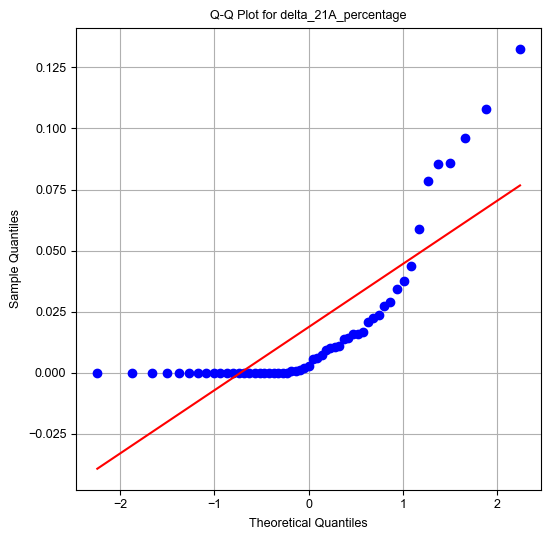

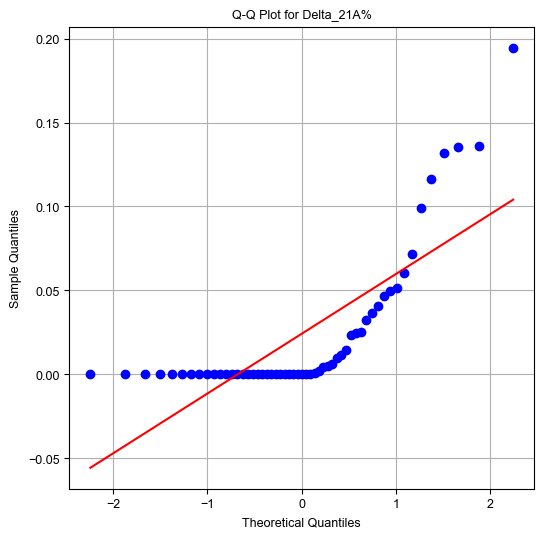

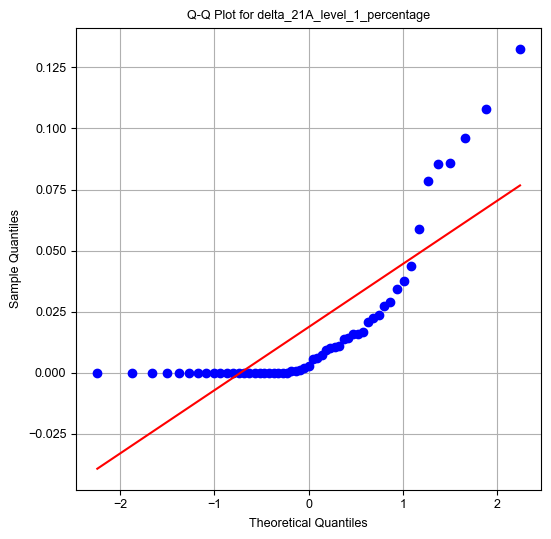

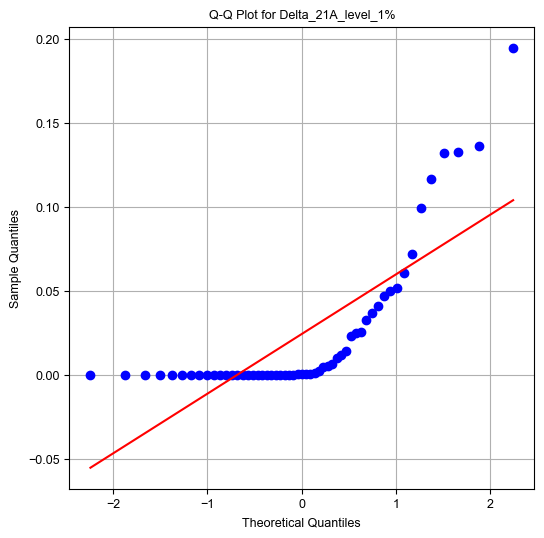

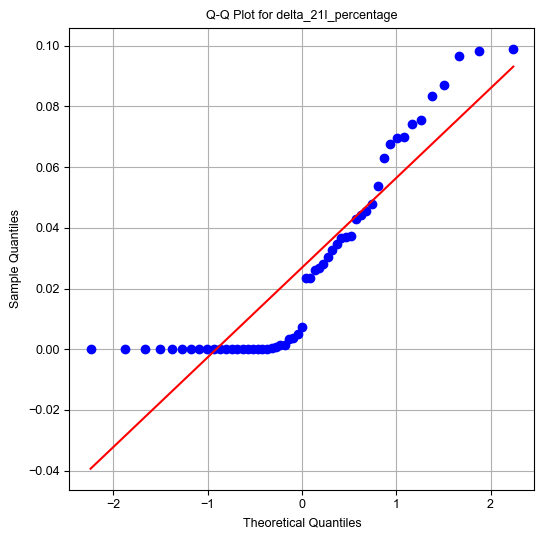

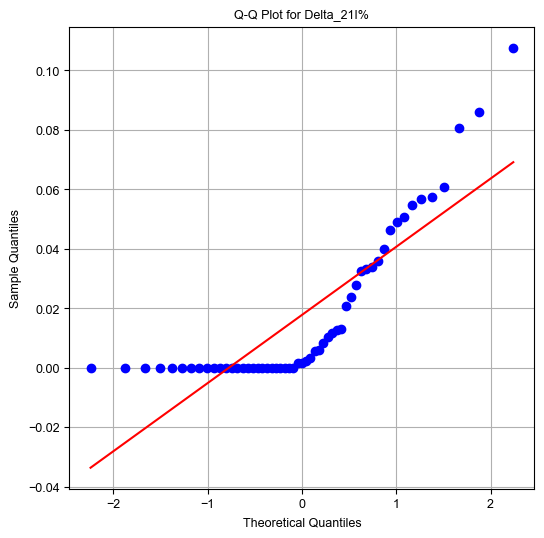

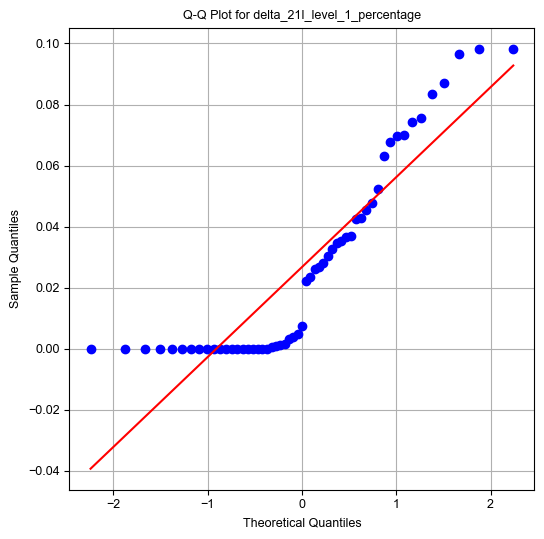

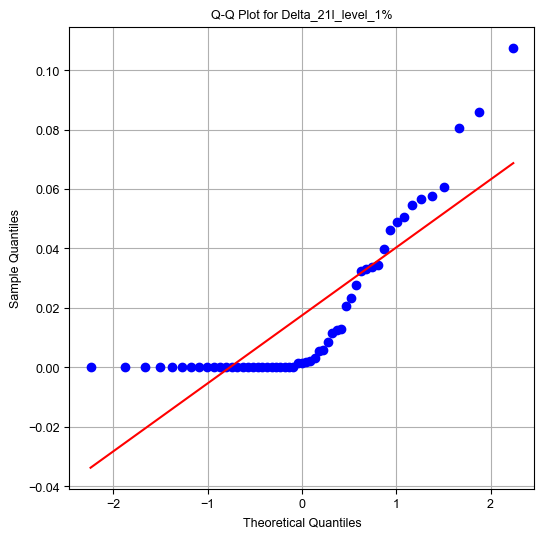

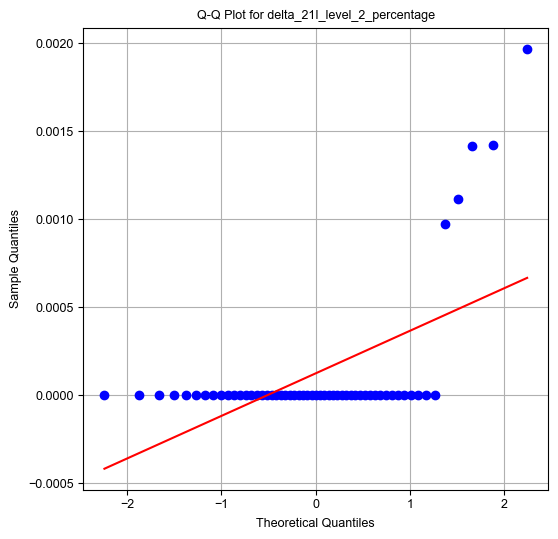

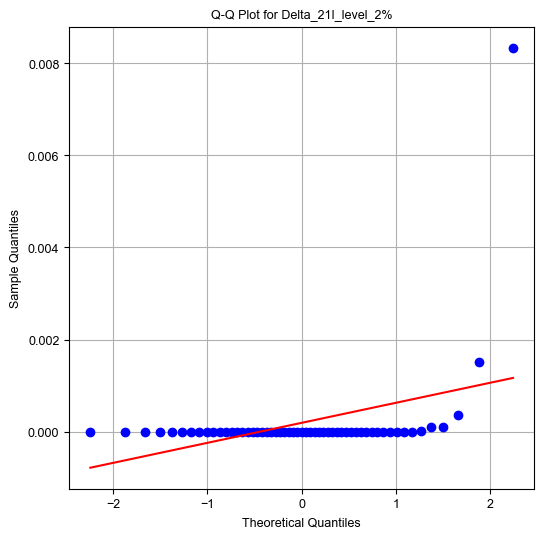

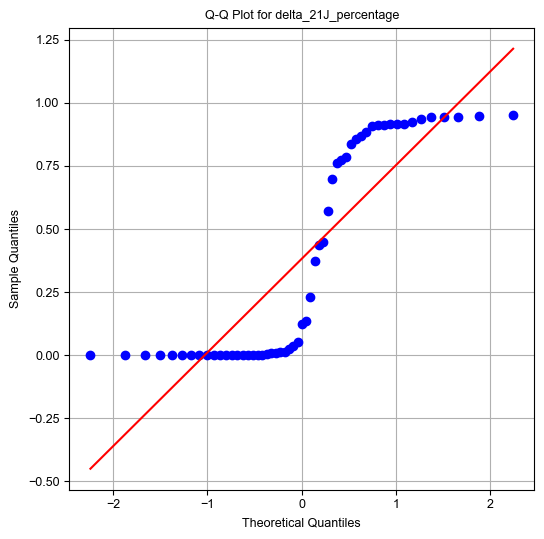

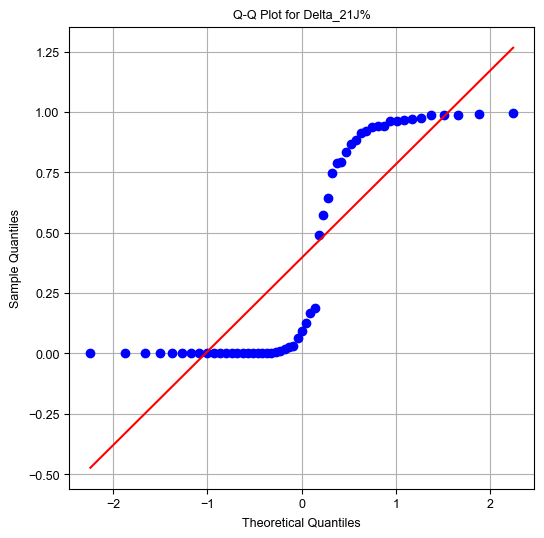

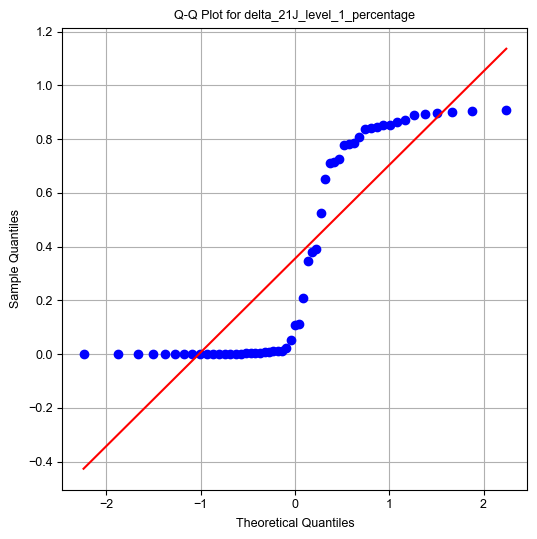

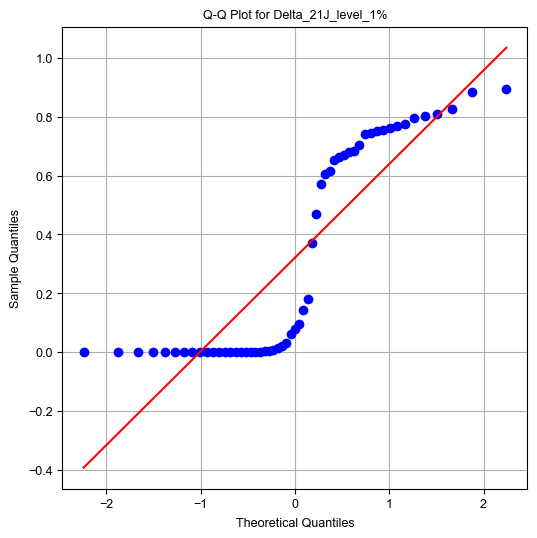

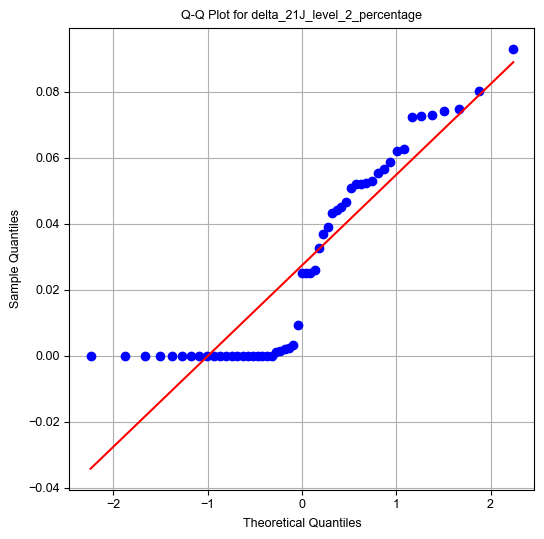

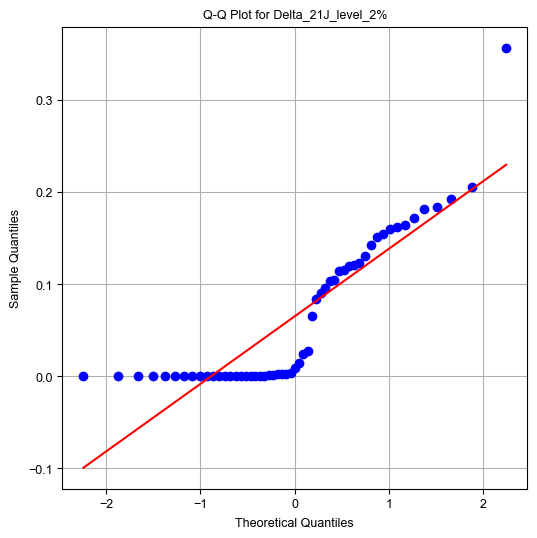

In [ ]:
from scipy.stats import probplot
import matplotlib.pyplot as plt
cli_columns = ['delta_21A_percentage', 'delta_21A_level_1_percentage', 'delta_21I_percentage','delta_21I_level_1_percentage', 'delta_21I_level_2_percentage','delta_21J_percentage', 'delta_21J_level_1_percentage','delta_21J_level_2_percentage']
ww_columns = ['Delta_21A%', 'Delta_21A_level_1%', 'Delta_21I%', 'Delta_21I_level_1%', 'Delta_21I_level_2%', 'Delta_21J%', 'Delta_21J_level_1%', 'Delta_21J_level_2%']

# Define a function to create Q-Q plot
def qq_plot(data, title):
    plt.figure(figsize=(6, 6))
    probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.grid(True)
    plt.show()

# Create Q-Q plots for each column
for cli_col, ww_col in zip(cli_columns, ww_columns):
    qq_plot(combined_study_cleandf[cli_col], title=f"Q-Q Plot for {cli_col}")
    qq_plot(combined_study_cleandf[ww_col], title=f"Q-Q Plot for {ww_col}")


## Figure 3 and Table 3 for the manuscript

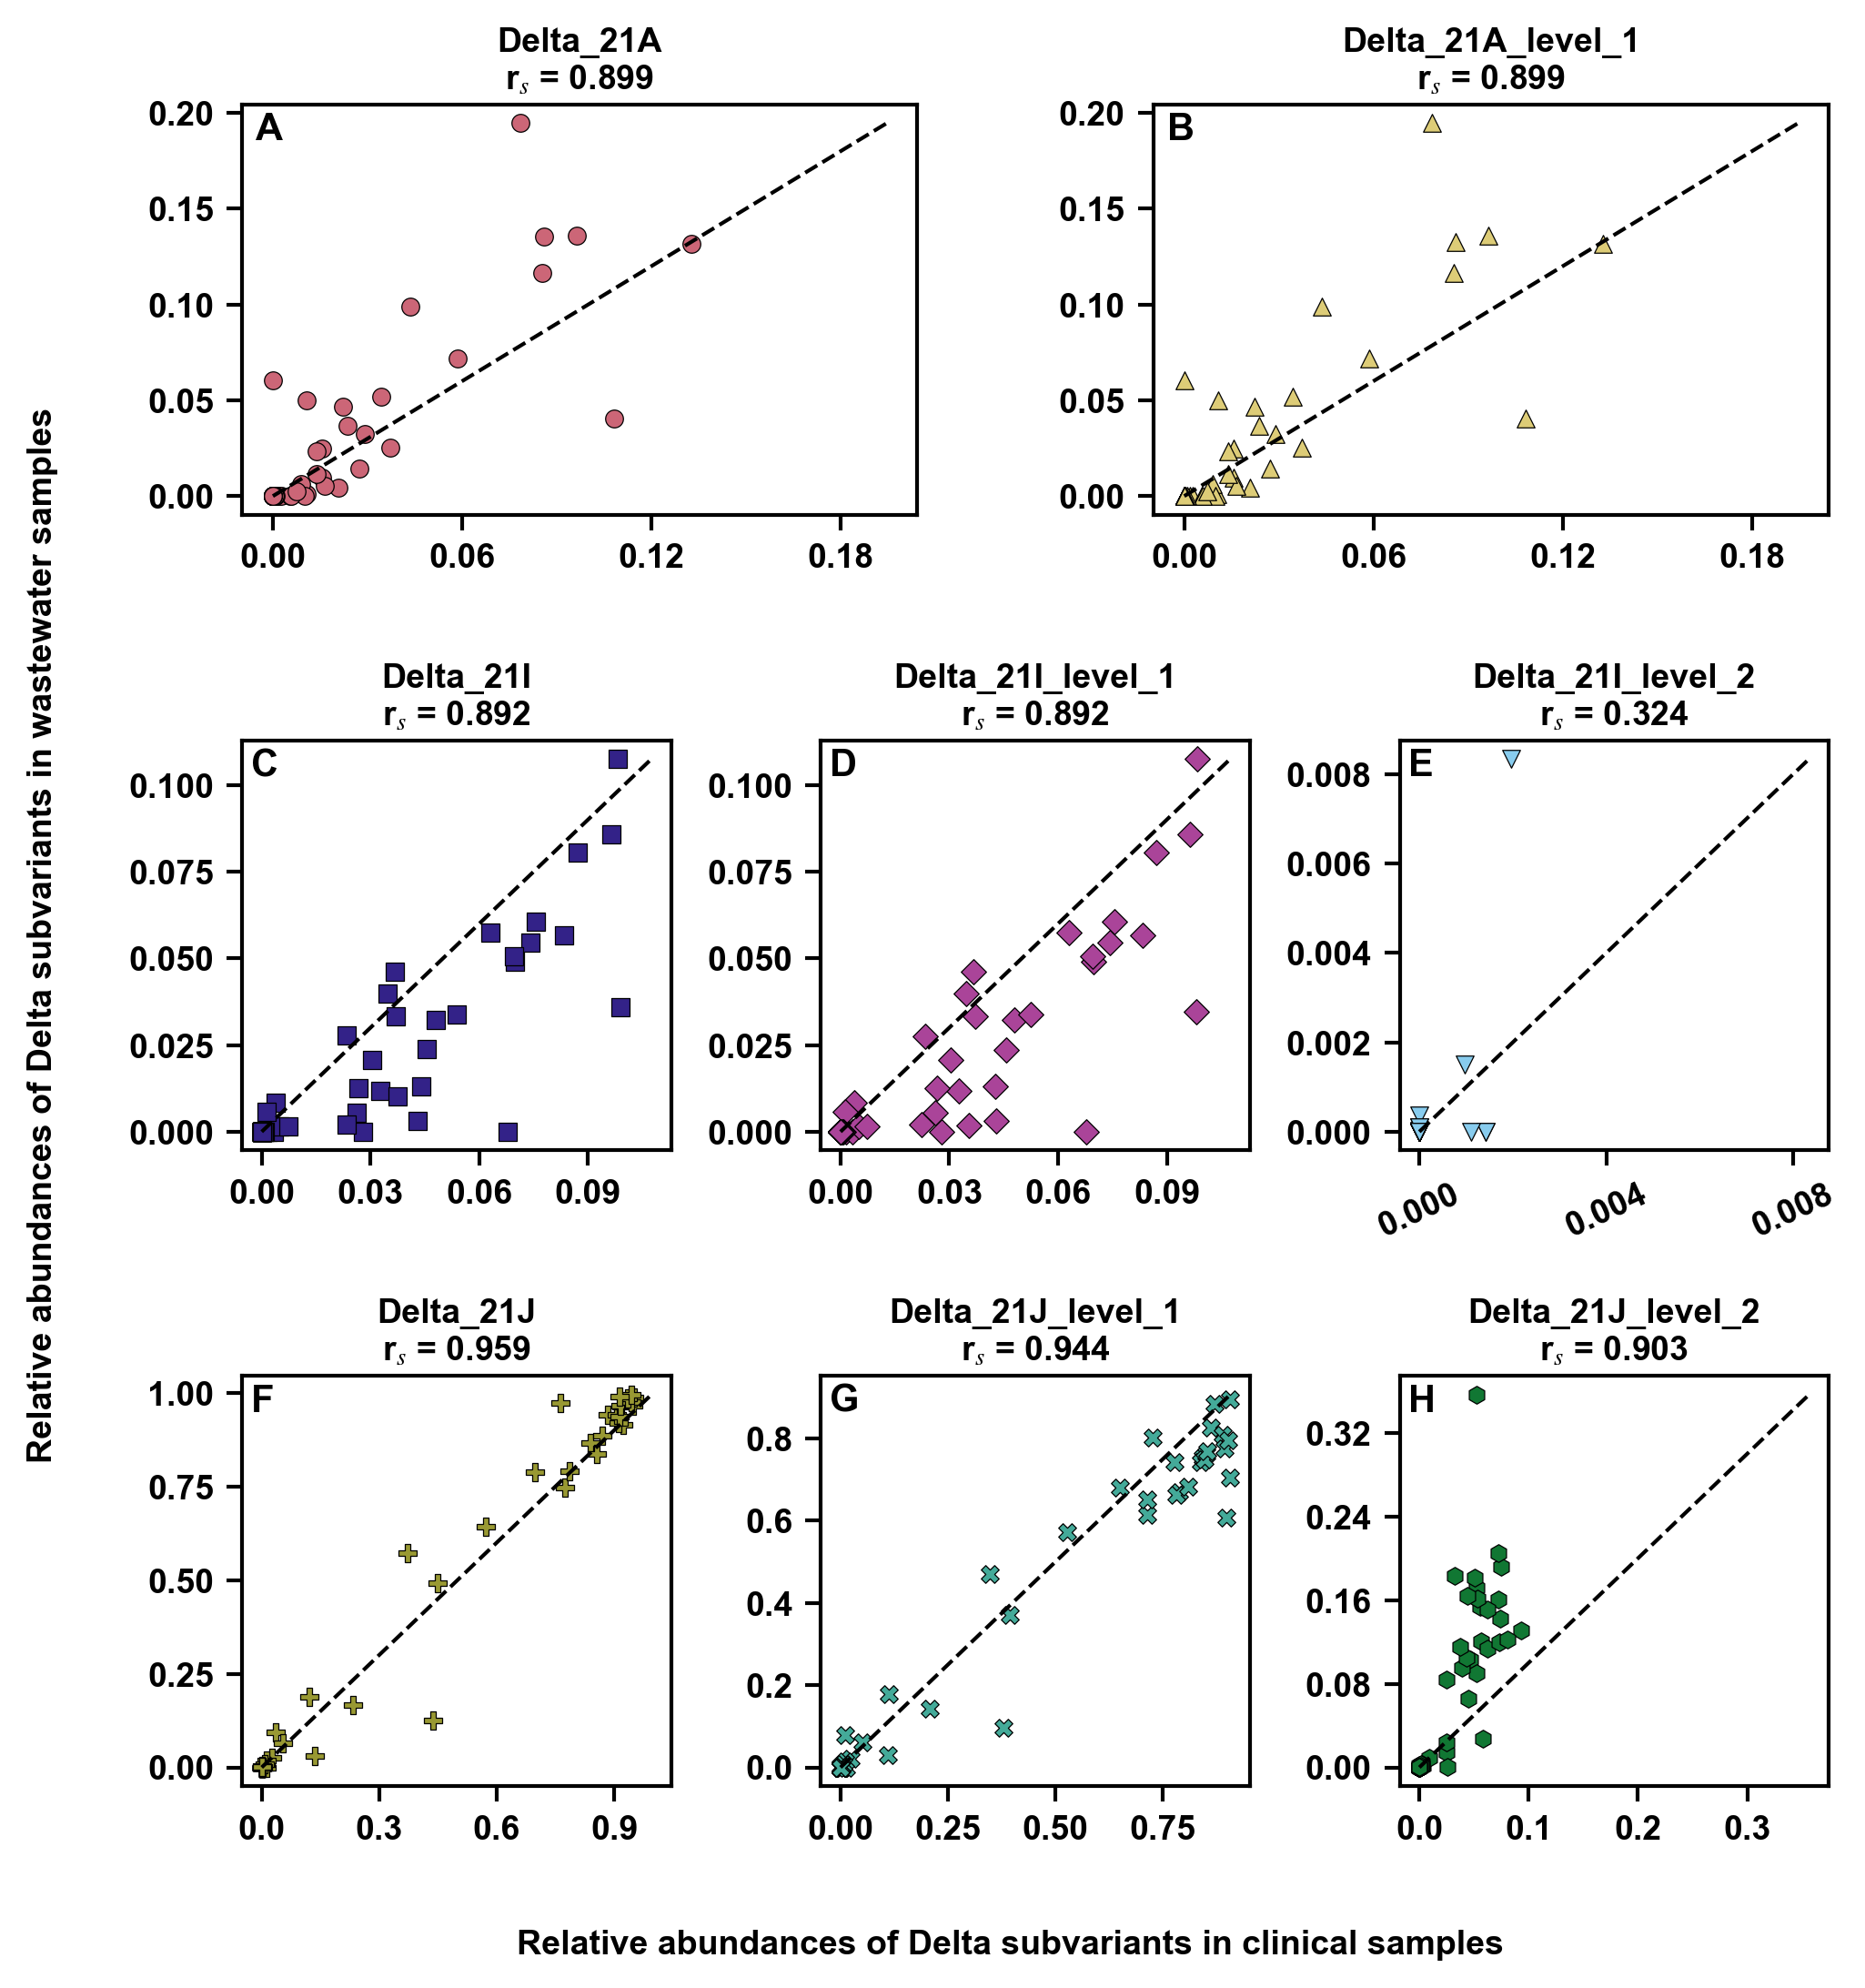

,Clade,Spearman r_s
0,Delta_21A,0.899
1,Delta_21A_level_1,0.899
2,Delta_21I,0.892
3,Delta_21I_level_1,0.892
4,Delta_21I_level_2,0.324
5,Delta_21J,0.959
6,Delta_21J_level_1,0.944
7,Delta_21J_level_2,0.903
8,Overall,0.923


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from matplotlib import font_manager

# Font handling

available_fonts = [f.name for f in font_manager.fontManager.ttflist]

if 'Arial' in available_fonts:
    chosen_font = 'Arial'
elif 'Times New Roman' in available_fonts:
    chosen_font = 'Times New Roman'
else:
    chosen_font = 'DejaVu Serif'

plt.rcParams.update({
    'font.family': chosen_font,
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# Data columns

cli_columns = ['delta_21A_percentage', 'delta_21A_level_1_percentage', 'delta_21I_percentage', 'delta_21I_level_1_percentage', 'delta_21I_level_2_percentage', 'delta_21J_percentage', 'delta_21J_level_1_percentage', 'delta_21J_level_2_percentage']
ww_columns = ['Delta_21A%', 'Delta_21A_level_1%', 'Delta_21I%', 'Delta_21I_level_1%', 'Delta_21I_level_2%', 'Delta_21J%', 'Delta_21J_level_1%', 'Delta_21J_level_2%']
clade_names = ['Delta_21A', 'Delta_21A_level_1', 'Delta_21I', 'Delta_21I_level_1', 'Delta_21I_level_2', 'Delta_21J', 'Delta_21J_level_1', 'Delta_21J_level_2']
colors = ['#CC6677', '#DDCC77', '#332288', '#AA4499', '#88CCEE', '#999933', '#44AA99', '#117733']
markers = ['o', '^', 's', 'D', 'v', 'P', 'X', 'h']

# This list stores the correlation results.
results = []

# Figure and layout
fig = plt.figure(figsize=(7.5, 8), dpi=300)
outer = GridSpec(3, 1, figure=fig, hspace=0.55)

gs_row1 = outer[0].subgridspec(1, 2, wspace=0.35)
gs_row2 = outer[1].subgridspec(1, 3, wspace=0.35)
gs_row3 = outer[2].subgridspec(1, 3, wspace=0.35)

axes = [
    fig.add_subplot(gs_row1[0, 0]),
    fig.add_subplot(gs_row1[0, 1]),
    fig.add_subplot(gs_row2[0, 0]),
    fig.add_subplot(gs_row2[0, 1]),
    fig.add_subplot(gs_row2[0, 2]),
    fig.add_subplot(gs_row3[0, 0]),
    fig.add_subplot(gs_row3[0, 1]),
    fig.add_subplot(gs_row3[0, 2])
]

panel_labels = list('ABCDEFGH')

# -----------------------------
# Plot loop
# -----------------------------
for i, (cli_col, ww_col, color, marker, name) in enumerate(
    zip(cli_columns, ww_columns, colors, markers, clade_names)
):
    ax = axes[i]

    # Retain rows where both clinical and wastewater values exist.
    paired_data = combined_study_cleandf[[cli_col, ww_col]].copy()
    paired_data[cli_col] = pd.to_numeric(paired_data[cli_col], errors='coerce')
    paired_data[ww_col] = pd.to_numeric(paired_data[ww_col], errors='coerce')
    paired_data = paired_data.replace([np.inf, -np.inf], np.nan).dropna()

    x_vals = paired_data[cli_col].to_numpy()
    y_vals = paired_data[ww_col].to_numpy()
    n_pairs = len(paired_data)

    # Spearman correlation requires at least two paired observations.
    # Constant values also produce an undefined correlation.
    if n_pairs >= 2 and np.unique(x_vals).size > 1 and np.unique(y_vals).size > 1:
        corr, p_value = spearmanr(x_vals, y_vals)
    else:
        corr, p_value = np.nan, np.nan

    results.append({
        'Clade': name,
        'Spearman r_s': corr,
    })

    # Scatter plot
    if n_pairs > 0:
        ax.scatter(
            x_vals,
            y_vals,
            color=color,
            marker=marker,
            s=22,
            edgecolors='black',
            linewidths=0.3
        )

        identity_max = float(max(np.max(x_vals), np.max(y_vals)))

        if identity_max > 0:
            ax.plot(
                [0, identity_max],
                [0, identity_max],
                color='black',
                linestyle='--',
                linewidth=1
            )

    corr_text = f'{corr:.3f}' if np.isfinite(corr) else 'NA'

    ax.set_title(
        f'{name}\nr$_s$ = {corr_text}',
        fontname=chosen_font,
        fontsize=9,
        fontweight='bold',
        pad=4
    )

    ax.text(
        0.02,
        0.98,
        panel_labels[i],
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        fontweight='bold',
        fontname=chosen_font
    )

    if n_pairs == 0:
        ax.text(
            0.5,
            0.5,
            'No paired data',
            transform=ax.transAxes,
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    if name == 'Delta_21I_level_2':
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.tick_params(axis='x', rotation=25)

    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        width=1,
        length=4
    )

    for tick in ax.get_xticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    for tick in ax.get_yticklabels():
        tick.set_fontname(chosen_font)
        tick.set_fontweight('bold')

    ax.xaxis.get_offset_text().set_fontsize(8)
    ax.yaxis.get_offset_text().set_fontsize(8)
    ax.xaxis.get_offset_text().set_fontweight('bold')
    ax.yaxis.get_offset_text().set_fontweight('bold')

    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Shared labels
fig.supxlabel(
    'Relative abundances of Delta subvariants in clinical samples',
    fontsize=9,
    fontweight='bold',
    fontname=chosen_font,
    y=0.03
)

fig.supylabel(
    'Relative abundances of Delta subvariants in wastewater samples',
    fontsize=9,
    fontweight='bold',
    fontname=chosen_font,
    x=0.02
)

# Overall statistics

overall_data = pd.DataFrame({
    'Clinical': combined_study_cleandf[cli_columns].to_numpy().flatten(),
    'Wastewater': combined_study_cleandf[ww_columns].to_numpy().flatten()
})

overall_data['Clinical'] = pd.to_numeric(
    overall_data['Clinical'],
    errors='coerce'
)

overall_data['Wastewater'] = pd.to_numeric(
    overall_data['Wastewater'],
    errors='coerce'
)

overall_data = overall_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

overall_n = len(overall_data)

if (
    overall_n >= 2
    and overall_data['Clinical'].nunique() > 1
    and overall_data['Wastewater'].nunique() > 1
):
    overall_corr, overall_p = spearmanr(
        overall_data['Clinical'],
        overall_data['Wastewater']
    )
else:
    overall_corr, overall_p = np.nan, np.nan

results.append({
    'Clade': 'Overall',
    'Spearman r_s': overall_corr,

})

# Save and show figure

plt.savefig(FIG5_PNG, dpi=300, bbox_inches='tight')
save_plos_tiff(fig, FIG5_TIFF)


plt.show()


# Display correlation results
results_df = pd.DataFrame(results)

results_df['Spearman r_s'] = results_df['Spearman r_s'].round(3)


display(results_df)

## Table 3: Delta subvariant correlations (circular block bootstrap)


In [ ]:
# TABLE 3: CLINICAL VS FREYJA DELTA SUBVARIANTS
# Circular block bootstrap confidence intervals
table3_df = prepare_dataframe(
    pd.read_excel(require_generated_file(TABLE3_PATH, 'Run the cell that saves COMBINED_RA_DELTA_PATH before this Table 3 cell.')),
    TABLE3_TIME,
    TABLE3_CLINICAL_COLUMNS + TABLE3_FREYJA_COLUMNS,
    'Table 3',
)

table3 = calculate_table(
    df=table3_df,
    time_column=TABLE3_TIME,
    left_columns=TABLE3_CLINICAL_COLUMNS,
    right_columns=TABLE3_FREYJA_COLUMNS,
    variant_names=TABLE3_VARIANTS,
    seed=RANDOM_SEED + 40_000,
)

table3.to_csv(TABLE3_CSV, index=False)
print(f'Saved Table 3 CSV to: {TABLE3_CSV}')

display(table3)


Saved Table 3 CSV to: /content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Tables/Table3.csv


,Variant,Spearman_rs,CBB_95%_CI
0,All,0.923,0.832 - 0.963
1,Delta_21A,0.899,0.718 - 0.963
2,Delta_21A_level_1,0.899,0.715 - 0.964
3,Delta_21I,0.892,0.725 - 0.958
4,Delta_21I_level_1,0.892,0.729 - 0.960
5,Delta_21I_level_2,0.324,-0.074 - 0.699
6,Delta_21J,0.959,0.876 - 0.983
7,Delta_21J_level_1,0.944,0.824 - 0.975
8,Delta_21J_level_2,0.903,0.695 - 0.951


## Save all three tables to one workbook


In [ ]:
with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:
    table1.to_excel(writer, sheet_name='Table1', index=False)
    table2.to_excel(writer, sheet_name='Table2', index=False)
    table3.to_excel(writer, sheet_name='Table3', index=False)

print('Saved workbook:')
print(OUTPUT_EXCEL)


Saved workbook:
/content/drive/MyDrive/Freyja_Manuscript/Master_File/Output_08012026/Tables/Tables_1_2_3.xlsx
